# MODELLING

## Import the necessary libraries

In [1]:

# Data manipulation


import numpy as np
import pandas as pd


# File handling


from pathlib import Path

# Regular expressions


import re


# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Warnings


import warnings

warnings.filterwarnings("ignore")


# Scikit-learn: Data splitting and cross-validation


from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)


# Scikit-learn: Preprocessing


from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline


# Scikit-learn: Models


from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from catboost import CatBoostClassifier

# Gradient Boosting Models


from xgboost import XGBClassifier

from lightgbm import LGBMClassifier


# Imbalanced-learn


from imblearn.pipeline import Pipeline as ImbPipeline

from imblearn.over_sampling import SMOTE

# Evaluation metrics


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    brier_score_loss
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression


# Calibration


from sklearn.calibration import calibration_curve


# Model interpretation


import shap

# Model saving
import joblib

import pickle

from datetime import datetime


# Display options


pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_rows",
    100
)

## 1. Load the data set after the feature engineering

In [2]:
# Define the output folder
OUTPUT_DIR = Path("./output")
train = pd.read_parquet(
    OUTPUT_DIR / "train_feature_engineered.parquet"
)

test = pd.read_parquet(
    OUTPUT_DIR / "test_feature_engineered.parquet"
)

print(train.shape)
print(test.shape)

(307511, 757)
(48744, 756)


## 2. Inspect the loaded data

In [3]:
# View dataset information
print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (307511, 757)
Test shape: (48744, 756)


,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_SUM,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_MAX,BUREAU_CREDIT_DAY_OVERDUE_MEAN,BUREAU_CREDIT_DAY_OVERDUE_SUM,BUREAU_CREDIT_DAY_OVERDUE_MIN,BUREAU_CREDIT_DAY_OVERDUE_MAX,BUREAU_DAYS_CREDIT_ENDDATE_MEAN,BUREAU_DAYS_CREDIT_ENDDATE_SUM,BUREAU_DAYS_CREDIT_ENDDATE_MIN,BUREAU_DAYS_CREDIT_ENDDATE_MAX,BUREAU_DAYS_ENDDATE_FACT_MEAN,BUREAU_DAYS_ENDDATE_FACT_SUM,BUREAU_DAYS_ENDDATE_FACT_MIN,BUREAU_DAYS_ENDDATE_FACT_MAX,BUREAU_AMT_CREDIT_MAX_OVERDUE_MEAN,BUREAU_AMT_CREDIT_MAX_OVERDUE_SUM,BUREAU_AMT_CREDIT_MAX_OVERDUE_MIN,BUREAU_AMT_CREDIT_MAX_OVERDUE_MAX,BUREAU_CNT_CREDIT_PROLONG_MEAN,BUREAU_CNT_CREDIT_PROLONG_SUM,BUREAU_CNT_CREDIT_PROLONG_MIN,BUREAU_CNT_CREDIT_PROLONG_MAX,BUREAU_AMT_CREDIT_SUM_MEAN,BUREAU_AMT_CREDIT_SUM_SUM,BUREAU_AMT_CREDIT_SUM_MIN,BUREAU_AMT_CREDIT_SUM_MAX,BUREAU_AMT_CREDIT_SUM_DEBT_MEAN,BUREAU_AMT_CREDIT_SUM_DEBT_SUM,BUREAU_AMT_CREDIT_SUM_DEBT_MIN,BUREAU_AMT_CREDIT_SUM_DEBT_MAX,BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN,BUREAU_AMT_CREDIT_SUM_LIMIT_SUM,BUREAU_AMT_CREDIT_SUM_LIMIT_MIN,BUREAU_AMT_CREDIT_SUM_LIMIT_MAX,BUREAU_AMT_CREDIT_SUM_OVERDUE_MEAN,BUREAU_AMT_CREDIT_SUM_OVERDUE_SUM,BUREAU_AMT_CREDIT_SUM_OVERDUE_MIN,BUREAU_AMT_CREDIT_SUM_OVERDUE_MAX,BUREAU_DAYS_CREDIT_UPDATE_MEAN,BUREAU_DAYS_CREDIT_UPDATE_SUM,BUREAU_DAYS_CREDIT_UPDATE_MIN,BUREAU_DAYS_CREDIT_UPDATE_MAX,BUREAU_AMT_ANNUITY_MEAN,BUREAU_AMT_ANNUITY_SUM,BUREAU_AMT_ANNUITY_MIN,BUREAU_AMT_ANNUITY_MAX,BUREAU_BB_MONTHS_COUNT_MEAN,BUREAU_BB_MONTHS_COUNT_SUM,BUREAU_BB_MONTHS_COUNT_MIN,BUREAU_BB_MONTHS_COUNT_MAX,BUREAU_BB_MONTHS_MIN_MEAN,BUREAU_BB_MONTHS_MIN_SUM,BUREAU_BB_MONTHS_MIN_MIN,BUREAU_BB_MONTHS_MIN_MAX,BUREAU_BB_MONTHS_MAX_MEAN,BUREAU_BB_MONTHS_MAX_SUM,BUREAU_BB_MONTHS_MAX_MIN,BUREAU_BB_MONTHS_MAX_MAX,BUREAU_BB_STATUS_0_MEAN,BUREAU_BB_STATUS_0_SUM,BUREAU_BB_STATUS_0_MIN,BUREAU_BB_S

## 3. Check data types

In [4]:
# Check feature types
numeric_cols = train.select_dtypes(include="number").columns.tolist()

categorical_cols = train.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

categorical_cols

Numeric columns: 741
Categorical columns: 16


['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

## 4. Separate the target and IDs

In [5]:
# Target variable
y = train["TARGET"]

# IDs
train_ids = train["SK_ID_CURR"]
test_ids = test["SK_ID_CURR"]

# Feature matrices
X = train.drop(columns=["TARGET", "SK_ID_CURR"])
X_test = test.drop(columns=["SK_ID_CURR"])

print(X.shape)
print(X_test.shape)

(307511, 755)
(48744, 755)


## 5. Identify categorical columns

In [6]:
categorical_cols = X.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print(f"Categorical columns: {len(categorical_cols)}")
categorical_cols

Categorical columns: 16


['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

## 6. Encoding

#### Step 1: Cardinality check

Check the number of unique categories of each categorical feature. This will help in identfying what type of encoding should I consider

In [7]:
# Check the number of unique values in each categorical feature

cardinality = (
    X[categorical_cols]
    .nunique()
    .sort_values(ascending=False)
    .to_frame(name="Unique Categories")
)

display(cardinality)

,Unique Categories
ORGANIZATION_TYPE,58
OCCUPATION_TYPE,19
NAME_INCOME_TYPE,8
NAME_TYPE_SUITE,8
WALLSMATERIAL_MODE,8
WEEKDAY_APPR_PROCESS_START,7
NAME_FAMILY_STATUS,6
NAME_HOUSING_TYPE,6
NAME_EDUCATION_TYPE,5
FONDKAPREMONT_MODE,5


### Cardinality Analysis

Cardinality analysis was performed to determine the number of unique categories in each categorical feature before choosing an encoding method. Most categorical variables had a small number of unique categories, ranging from 2 to 19. For example, `NAME_CONTRACT_TYPE`, `FLAG_OWN_CAR`, and `FLAG_OWN_REALTY` had only 2 unique categories, while `OCCUPATION_TYPE` had 19 categories.

The feature with the highest cardinality was `ORGANIZATION_TYPE`, which contained 58 unique categories. To reduce the number of dummy variables created during encoding and improve model efficiency, only the 15 most frequent organization types will be retained, while the remaining less frequent categories will be grouped into a single category labelled **"Other"**.

Overall, the dataset contains mostly low-cardinality categorical variables. Therefore, One-Hot Encoding is an appropriate encoding technique. Grouping the rare `ORGANIZATION_TYPE` categories before encoding helps reduce dimensionality while preserving the most important information in the data.

In [8]:
# Check categories for the two highest-cardinality features

for col in ["ORGANIZATION_TYPE"]:
    print("=" * 60)
    print(f"{col}")
    print("=" * 60)

    print(f"Number of unique categories: {X[col].nunique()}\n")

    display(
        X[col]
        .value_counts(dropna=False)
        .to_frame(name="Count")
    )

ORGANIZATION_TYPE
Number of unique categories: 58



,Count
ORGANIZATION_TYPE,
Business Entity Type 3,67992
XNA,55374
Self-employed,38412
Other,16683
Medicine,11193
Business Entity Type 2,10553
Government,10404
School,8893
Trade: type 7,7831


##### Step 2: Reduce cardinality of ORGANIZATION_TYPE

In [9]:
# Keep the top 15 categories
top_15_org = (
    X["ORGANIZATION_TYPE"]
    .value_counts()
    .nlargest(15)
    .index
)

# Group the rest into "Other"
for df in [X, X_test]:
    df["ORGANIZATION_TYPE"] = np.where(
        df["ORGANIZATION_TYPE"].isin(top_15_org),
        df["ORGANIZATION_TYPE"],
        "Other"
    )

print(X["ORGANIZATION_TYPE"].nunique())
print(X["ORGANIZATION_TYPE"].value_counts())

15
ORGANIZATION_TYPE
Business Entity Type 3    67992
Other                     65016
XNA                       55374
Self-employed             38412
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Construction               6721
Business Entity Type 1     5984
Transport: type 4          5398
Trade: type 3              3492
Industry: type 9           3368
Name: count, dtype: int64


In [10]:
print("Training set:")
print(X["ORGANIZATION_TYPE"].nunique())

print("\nTest set:")
print(X_test["ORGANIZATION_TYPE"].nunique())

Training set:
15

Test set:
15


## 7. Encode categorical features and scale numeric features

In [11]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=False,
    dtype="int8"
)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=False,
    dtype="int8"
)

X, X_test = X.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

##### Aligning train and test

In [12]:
# Ensure train and test have identical columns

X, X_test = X.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

#### Verify the encoding

In [13]:
# Recompute feature types

numeric_cols = X.select_dtypes(include="number").columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

Numeric columns: 842
Categorical columns: 0


#### Clean the column names

In [14]:


def clean_column_names(df):
    df = df.copy()

    df.columns = [
        re.sub(r'[^A-Za-z0-9_]', '_', col)
        for col in df.columns
    ]

    return df

In [15]:
X = clean_column_names(X)
X_test = clean_column_names(X_test)

## 8. Train / validation split

##### Splitting  the data

In [16]:


# Split into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Validation features:", X_valid.shape)
print("Training target:", y_train.shape)
print("Validation target:", y_valid.shape)

Training features: (246008, 842)
Validation features: (61503, 842)
Training target: (246008,)
Validation target: (61503,)


##### Verify the class distribution

This confirms that stratification worked correctly.

In [17]:
print("Original target distribution:")
print(y.value_counts(normalize=True))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation target distribution:")
print(y_valid.value_counts(normalize=True))

Original target distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Training target distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Validation target distribution:
TARGET
0    0.919272
1    0.080728
Name: proportion, dtype: float64


## 9. Handle class imbalance with SMOTE

In [18]:

# Handle Class Imbalance using SMOTE


smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_smote.value_counts())

Before SMOTE
TARGET
0    226148
1     19860
Name: count, dtype: int64

After SMOTE
TARGET
0    226148
1    226148
Name: count, dtype: int64


In [19]:
print("Duplicate columns:", X.columns.duplicated().sum())

Duplicate columns: 0


To address the class imbalance in the training data, the Synthetic Minority Oversampling Technique (SMOTE) was applied after splitting the dataset into training and validation sets. This ensured that only the training data was balanced, preventing data leakage into the validation set.

## 10. Scale the Data (Logistic Regression Only)

In [20]:

# Feature Scaling

scaler = StandardScaler()

# Logistic Regression
X_train_scaled = scaler.fit_transform(X_train_smote)

X_valid_scaled = scaler.transform(X_valid)

X_test_scaled = scaler.transform(X_test) 

## 11. Create an Evaluation Function
To avoid writing the same evaluation code for every model.

In [21]:

results = []

def evaluate_model(model_name, y_true, y_pred, y_prob):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    })

## 12. Train the Baseline Models


#### 1. Logistic Regression

In [22]:

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)
log_model.fit(X_train_scaled, y_train_smote)

log_pred = log_model.predict(X_valid_scaled)

log_prob = log_model.predict_proba(X_valid_scaled)[:, 1]

evaluate_model(
    "Logistic Regression",
    y_valid,
    log_pred,
    log_prob
)

Logistic Regression was trained using the scaled SMOTE-balanced training data because it is sensitive to feature magnitudes.

#### 2. Cat boost

In [23]:
catboost_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100
)

catboost_model.fit(
    X_train_smote,
    y_train_smote,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=50
)

catboost_pred = (
    catboost_model.predict(X_valid)
    .astype(int)
    .ravel()
)

catboost_prob = catboost_model.predict_proba(X_valid)[:, 1]

evaluate_model(
    "CatBoost",
    y_valid,
    catboost_pred,
    catboost_prob
)

0:	test: 0.6319448	best: 0.6319448 (0)	total: 2.17s	remaining: 10m 49s
100:	test: 0.7636709	best: 0.7636709 (100)	total: 1m 55s	remaining: 3m 47s
200:	test: 0.7756874	best: 0.7756874 (200)	total: 3m 28s	remaining: 1m 42s
299:	test: 0.7803384	best: 0.7803384 (299)	total: 4m 47s	remaining: 0us

bestTest = 0.7803384133
bestIteration = 299



#### 3. Random Forest

In [24]:


rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

rf_pred = rf_model.predict(X_valid)

rf_prob = rf_model.predict_proba(X_valid)[:,1]

evaluate_model(
    "Random Forest",
    y_valid,
    rf_pred,
    rf_prob
)

#### 4. XGBoost

In [25]:


xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_smote, y_train_smote)

xgb_pred = xgb_model.predict(X_valid)

xgb_prob = xgb_model.predict_proba(X_valid)[:,1]

evaluate_model(
    "XGBoost",
    y_valid,
    xgb_pred,
    xgb_prob
)

#### 5. LightGBM

In [26]:
# Train the original LightGBM model

lgbm_model = LGBMClassifier(
    random_state=42
)

lgbm_model.fit(
    X_train_smote,
    y_train_smote
)
# Generate LightGBM predictions

lgbm_pred = lgbm_model.predict(X_valid)

lgbm_prob = lgbm_model.predict_proba(
    X_valid
)[:, 1]

# Evaluate LightGBM

evaluate_model(
    "LightGBM",
    y_valid,
    lgbm_pred,
    lgbm_prob
)

[LightGBM] [Info] Number of positive: 226148, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 5.222704 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 146005
[LightGBM] [Info] Number of data points in the train set: 452296, number of used features: 826
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


Cat Boost, Random Forest, XGBoost, and LightGBM were trained using the SMOTE-balanced training data without feature scaling, as tree-based algorithms are generally not affected by differences in feature scale.

#### Compare the Models

In [27]:
results_df = (
    pd.DataFrame(results)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,LightGBM,0.919874,0.585253,0.025579,0.049016,0.782312
1,CatBoost,0.920248,0.659574,0.024975,0.048127,0.780338
2,Logistic Regression,0.920085,0.567568,0.042296,0.078725,0.778633
3,XGBoost,0.918849,0.481322,0.067472,0.118354,0.773867
4,Random Forest,0.919288,0.507692,0.006647,0.013121,0.735242



The baseline model comparison shows that LightGBM achieved the highest ROC-AUC score of 0.782312, making it the strongest model for predicting loan default based on ranking ability. CatBoost followed closely with a ROC-AUC of 0.780338, performing very closely to LightGBM. Logistic Regression achieved a ROC-AUC of 0.778633, while XGBoost achieved 0.773867. Random Forest performed lower, with a ROC-AUC of 0.735242.


Although LightGBM achieved the highest ROC-AUC, CatBoost recorded the highest precision at 65.96%. This means that when CatBoost predicted a customer as a defaulter, its predictions were more likely to be correct. However, its recall was only 2.50%, meaning that it still missed most actual defaulters. LightGBM had a slightly higher recall of 2.56%, while Logistic Regression and XGBoost achieved 4.23% and 6.75% respectively. XGBoost therefore identified more actual defaulters at the default 0.5 threshold, but its precision was lower at 48.13%. XGBoost also achieved the highest F1-score at 0.118354, indicating a better balance between precision and recall compared with the other baseline models.



All five models achieved approximately 92% accuracy. However, accuracy is misleading in this case because the dataset is imbalanced, with defaulters representing only about 8% of the data. A model can therefore achieve high accuracy by predicting most customers as non-defaulters while still missing a large proportion of actual defaulters. This is reflected in the very low recall scores across the models.

Since credit risk prediction is an imbalanced classification problem, ROC-AUC provides a more useful measure of overall model discrimination than accuracy alone, as it evaluates the model's ability to distinguish between defaulters and non-defaulters across different classification thresholds. Based on the baseline results, LightGBM was selected as the current best-performing model, with CatBoost remaining a close alternative. XGBoost also showed potential due to its higher recall and F1-score. All models will be further evaluated through hyperparameter tuning before making the final model selection. Particular attention will also be given to classification threshold selection because the default 0.5 threshold results in very low defaulter recall across all models.



## 13. Classification Report

The classification report code was used to evaluate and compare the performance of the five credit-risk models on the validation data. It generates precision, recall, F1-score, and accuracy for both non-defaulters and defaulters. Logistic Regression uses the scaled validation data because it was trained on scaled data, while the tree-based models use the unscaled validation data. The validation data remains untouched by SMOTE, ensuring that the evaluation reflects the models' performance on realistic data.

In [28]:
# CLASSIFICATION REPORTS FOR CURRENT CREDIT RISK MODELS

# Store the models that have already been trained
models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model,
    "CatBoost": catboost_model
}

# Generate classification reports
for name, model in models.items():

    # Logistic Regression was trained using scaled data
    if name == "Logistic Regression":

        predictions = model.predict(X_valid_scaled)

    # Tree-based models were trained without scaling
    else:

        predictions = model.predict(X_valid)


    # Display model name
    print(f"\n{name} Classification Report")

    print("-" * 60)


    # Display classification report
    print(
        classification_report(
            y_valid,
            predictions,
            target_names=[
                "Non-Defaulter",
                "Defaulter"
            ]
        )
    )


Logistic Regression Classification Report
------------------------------------------------------------
               precision    recall  f1-score   support

Non-Defaulter       0.92      1.00      0.96     56538
    Defaulter       0.57      0.04      0.08      4965

     accuracy                           0.92     61503
    macro avg       0.74      0.52      0.52     61503
 weighted avg       0.89      0.92      0.89     61503


Random Forest Classification Report
------------------------------------------------------------
               precision    recall  f1-score   support

Non-Defaulter       0.92      1.00      0.96     56538
    Defaulter       0.51      0.01      0.01      4965

     accuracy                           0.92     61503
    macro avg       0.71      0.50      0.49     61503
 weighted avg       0.89      0.92      0.88     61503


XGBoost Classification Report
------------------------------------------------------------
               precision    recall  f1-s

## Model Classification Report Interpretation

Five machine learning models were evaluated on the validation set, which contained **56,538 non-defaulters and 4,965 defaulters**.

All models achieved approximately **92% accuracy**. However, accuracy is not a reliable measure of performance in this case because the dataset is highly imbalanced. Since only about 8% of applicants are defaulters, a model can achieve high accuracy simply by predicting most applicants as non-defaulters.

Therefore, greater attention was given to the **Defaulter class**, particularly **precision, recall, and F1-score**.

- **Logistic Regression:** Achieved **57% precision and 4% recall** for defaulters. This means that when the model predicts default, it is correct 57% of the time, but it identifies only a small proportion of actual defaulters.

- **Random Forest:** Achieved **51% precision and only 1% recall**. Although it achieved approximately 92% accuracy, it identified very few actual defaulters, making it less suitable for the credit-risk objective.

- **XGBoost:** Achieved **48% precision and 7% recall**, giving it the **highest recall among the baseline models**. It also achieved the highest defaulter F1-score of **12%**, indicating the best balance between precision and recall among the models at the default 0.50 threshold. However, it still missed the majority of actual defaulters.

- **LightGBM:** Achieved **59% precision and 3% recall**. Its defaulter predictions were relatively precise, but it identified only a small proportion of actual defaulters.

- **CatBoost:** Achieved the **highest defaulter precision at 66%**, meaning that its positive predictions were the most precise among the models. However, its recall was only **2%**, meaning that it missed most actual defaulters.

### Overall Finding

The baseline results show that all models performed well at identifying non-defaulters but struggled to identify the minority class of defaulters. This demonstrates the effect of the severe class imbalance in the dataset.

The results also show that **accuracy alone would give a misleading impression of model performance**. For example, Random Forest achieved 92% accuracy but detected only 1% of actual defaulters.

Among the baseline models:

- **CatBoost** had the highest defaulter precision (**66%**).
- **XGBoost** had the highest defaulter recall (**7%**) and F1-score (**12%**).
- **LightGBM** provided a competitive balance between precision and ROC-AUC while offering strong suitability for large, high-dimensional datasets.

 These  models will be further improved using **class weighting and hyperparameter tuning**.

This approach allows the models to give greater importance to the minority class rather than simply optimising for the majority class. Their performance will then be compared using **ROC-AUC, precision, recall, and F1-score**, followed by **threshold tuning and probability calibration** before selecting the final model.

## 14. ROC Curve comparison for credit risk models


An ROC curve shows how well a model separates the two classes - defaulters vs. non-defaulters - across every possible decision threshold

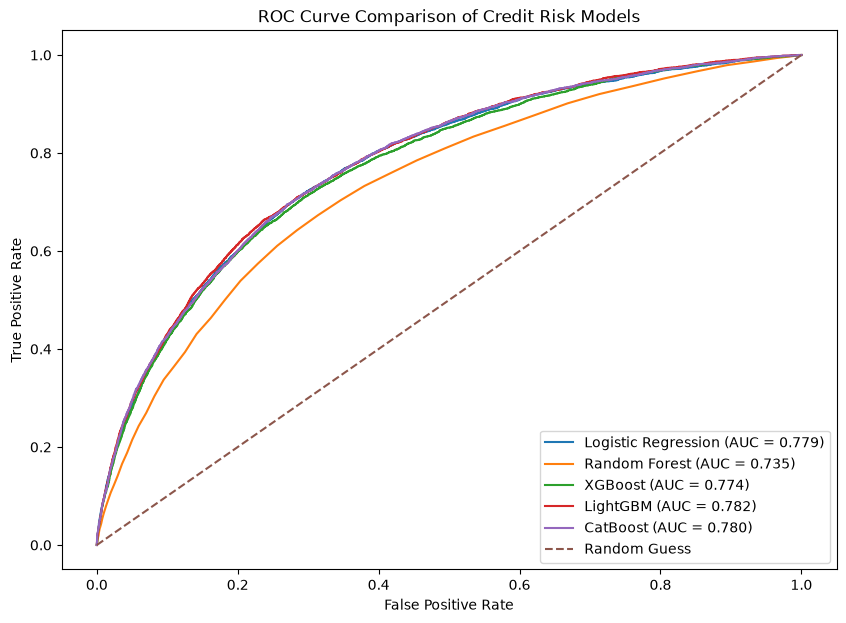

In [29]:
# Create the models dictionary

models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model,
    "CatBoost": catboost_model
}


# Create the ROC curve figure
plt.figure(figsize=(10, 7))


# Loop through all trained models

for name, model in models.items():

    
    # Logistic Regression uses scaled validation data
    
    # It was trained using X_train_scaled, so the validation data must also be scaled.

    if name == "Logistic Regression":

        # Get probability of the Defaulter class
        probs = model.predict_proba(
            X_valid_scaled
        )[:, 1]

    
    # Tree-based models use original validation data
    
    # Decision Tree, Random Forest, XGBoost, LightGBM and CatBoost
    # were trained without scaling.

    else:

        # Get probability of the Defaulter class
        probs = model.predict_proba(
            X_valid
        )[:, 1]


    # Calculate False Positive Rate and True Positive Rate

    fpr, tpr, _ = roc_curve(
        y_valid,
        probs
    )


    # Calculate ROC-AUC score

    auc = roc_auc_score(
        y_valid,
        probs
    )


    # Plot the ROC curve

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )


# Add the random prediction baseline

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)


# Add axis labels

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")


# Add title

plt.title(
    "ROC Curve Comparison of Credit Risk Models"
)


# Display legend

plt.legend()


# Display the plot

plt.show()

LightGBM (0.782), Logistic Regression (0.779), CatBoost (0.780), and XGBoost (0.774) performed very similarly, showing that they had comparable ability to rank customers according to their risk of default. LightGBM achieved the highest ROC-AUC, but the difference between the top models was very small. Random Forest (0.735) performed noticeably worse than the other models.

Overall, the ROC curves show that all five models performed better than random guessing, but there was no clear winner based on ROC-AUC alone. Therefore, additional metrics such as **precision, recall, F1-score, and classification threshold analysis** were considered to determine which model is most suitable for identifying potential loan defaulters.

## 15. Precision -recall curve comparison

The Precision-Recall curve shows how well the models identify defaulters while avoiding too many false alarms. It is especially useful because the dataset has many more non-defaulters than defaulters.

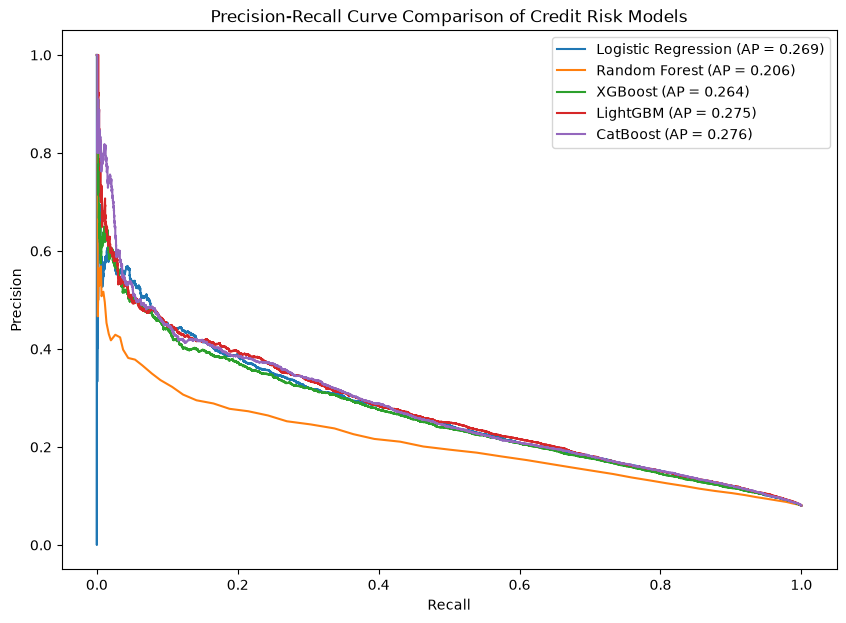

In [30]:

# Create dictionary of trained models

models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model,
    "CatBoost": catboost_model
}


# Set figure size


plt.figure(figsize=(10, 7))



# Loop through each trained model


for name, model in models.items():

    # Logistic Regression was trained using scaled data
    # Therefore, validation data must also be scaled

    if name == "Logistic Regression":

        probs = model.predict_proba(
            X_valid_scaled
        )[:, 1]

    # Tree-based models were trained without scaling

    else:

        probs = model.predict_proba(
            X_valid
        )[:, 1]


    # Calculate Precision and Recall


    precision, recall, _ = precision_recall_curve(
        y_valid,
        probs
    )

    # Calculate Average Precision (AP)


    ap = average_precision_score(
        y_valid,
        probs
    )


    # Plot the Precision-Recall curve


    plt.plot(
        recall,
        precision,
        label=f"{name} (AP = {ap:.3f})"
    )


# Add axis labels


plt.xlabel("Recall")

plt.ylabel("Precision")


# Add title


plt.title(
    "Precision-Recall Curve Comparison of Credit Risk Models"
)



# Display legend


plt.legend()


# Display the plot


plt.show()

CatBoost (AP = 0.276) achieved the highest Average Precision, closely followed by LightGBM (0.275), Logistic Regression (0.269), and XGBoost (0.264). Random Forest had the lowest Average Precision (0.206), indicating weaker performance in identifying the minority class of defaulters.

The Precision-Recall curves also show the trade-off between precision and recall. As the models are adjusted to identify more potential defaulters and recall increases, precision generally decreases. This means that increasing the number of customers identified as potential defaulters will also result in more false positive predictions.

Overall, CatBoost performed best based on Average Precision, although the difference between CatBoost, LightGBM, Logistic Regression, and XGBoost was relatively small. Since the models have low recall at the default 0.5 threshold, threshold tuning is important to find a suitable balance between identifying actual defaulters and maintaining acceptable precision.

## 16. Cross-Validated Baseline Comparison 

The leaderboard above is based on a single 80/20 train/validation split. With ROC-AUC scores that are relatively close, such as LightGBM's 0.782 and CatBoost's 0.780, the differences could be influenced by the particular split of the data.

Therefore, the comparison below checks how consistently the five models perform by dividing the training data into five groups and training each model five times, using a different group for validation each time. SMOTE is applied only to the training portion of each fold, while the validation portion remains unchanged. Logistic Regression is scaled because it requires feature scaling, while the tree-based models do not.

ROC-AUC is calculated for each fold, and the code then calculates the average ROC-AUC and standard deviation to show which model performs best overall and which model performs most consistently across different data splits.

In [31]:
cv_3fold = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Focus on the strongest baseline models
cv_pipelines = {

    "Logistic Regression": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            random_state=42,
            max_iter=1000
        ))
    ]),

    "XGBoost": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf", XGBClassifier(
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1
        ))
    ]),

    "LightGBM": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf", LGBMClassifier(
            random_state=42,
            verbosity=-1,
            n_jobs=-1
        ))
    ]),

    "CatBoost": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf", CatBoostClassifier(
            iterations=300,
            learning_rate=0.05,
            depth=6,
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=42,
            verbose=0
        ))
    ])
}


cv_results = []


# Run cross-validation

for name, pipe in cv_pipelines.items():

    print(f"Running {name}...")

    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv_3fold,
        scoring="roc_auc",
        n_jobs=1
    )

    cv_results.append({
        "Model": name,
        "CV ROC-AUC Mean": scores.mean(),
        "CV ROC-AUC Std": scores.std()
    })

    print(
        f"{name}: "
        f"ROC-AUC = {scores.mean():.4f} "
        f"(+/- {scores.std():.4f})"
    )


# Create results table

cv_results_df = (
    pd.DataFrame(cv_results)
    .sort_values(
        "CV ROC-AUC Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

display(cv_results_df)

Running Logistic Regression...
Logistic Regression: ROC-AUC = 0.7751 (+/- 0.0025)
Running XGBoost...
XGBoost: ROC-AUC = 0.7655 (+/- 0.0025)
Running LightGBM...
LightGBM: ROC-AUC = 0.7770 (+/- 0.0026)
Running CatBoost...
CatBoost: ROC-AUC = 0.7734 (+/- 0.0027)


,Model,CV ROC-AUC Mean,CV ROC-AUC Std
0,LightGBM,0.777008,0.002575
1,Logistic Regression,0.775083,0.002527
2,CatBoost,0.773408,0.002727
3,XGBoost,0.765521,0.002532


### Cross-Validation Results

Five-fold stratified cross-validation was performed on the four strongest baseline models using ROC-AUC as the evaluation metric. SMOTE was included inside each pipeline so that oversampling was applied only to the training portion of each fold, while the validation portion remained unchanged.

LightGBM achieved the highest mean CV ROC-AUC of 0.7770, followed by Logistic Regression at 0.7751. CatBoost achieved 0.7734, while XGBoost recorded the lowest mean ROC-AUC of 0.7655.

The standard deviations were very small for all four models (0.0025–0.0027), indicating that model performance was relatively consistent across the five folds.

Overall, LightGBM remained the strongest model based on cross-validation. However, the difference between LightGBM and Logistic Regression was very small (0.0019), while CatBoost also performed closely. Logistic Regression was therefore retained as a candidate for further tuning because of its competitive performance and stability, while CatBoost was also retained as an alternative tree-based model. XGBoost was excluded from further tuning because it recorded the lowest mean CV ROC-AUC.



## 17. SMOTE vs. Class-Weighting

SMOTE was used everywhere above, but it's not the only way to handle the 92/8 imbalance, and it's considerably more expensive than simply telling the model to weight the minority class more heavily. Here I train the two strongest baseline families - Logistic Regression and LightGBM - using class_weight='balanced /is_unbalance=True instead of SMOTE, on the *original* (non-resampled) training data, and compare against the SMOTE versions already in results_df.

In [32]:

# CLASS-WEIGHTING FOR TOP 3 MODELS

# 1. LOGISTIC REGRESSION


log_model_cw = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

# Scale original training data
X_train_scaled_cw = scaler.fit_transform(X_train)

# Scale validation data using the same scaler
X_valid_scaled_cw = scaler.transform(X_valid)

# Train on original imbalanced data
log_model_cw.fit(
    X_train_scaled_cw,
    y_train
)

# Predictions
log_cw_pred = log_model_cw.predict(
    X_valid_scaled_cw
)

log_cw_prob = log_model_cw.predict_proba(
    X_valid_scaled_cw
)[:, 1]

# Evaluate
evaluate_model(
    "Logistic Regression (class_weight)",
    y_valid,
    log_cw_pred,
    log_cw_prob
)


# 2. LIGHTGBM


lgbm_model_cw = LGBMClassifier(
    random_state=42,
    is_unbalance=True,
    verbosity=-1,
    n_jobs=-1
)

# Train on original imbalanced data
lgbm_model_cw.fit(
    X_train,
    y_train
)

# Predictions
lgbm_cw_pred = lgbm_model_cw.predict(
    X_valid
)

lgbm_cw_prob = lgbm_model_cw.predict_proba(
    X_valid
)[:, 1]

# Evaluate
evaluate_model(
    "LightGBM (class_weight)",
    y_valid,
    lgbm_cw_pred,
    lgbm_cw_prob
)


# 3. CATBOOST


catboost_model_cw = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights=[1, 11.39],
    random_seed=42,
    verbose=100
)

# Train on original imbalanced data
catboost_model_cw.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=50
)

# Predictions
catboost_cw_pred = (
    catboost_model_cw.predict(X_valid)
    .astype(int)
    .ravel()
)

catboost_cw_prob = (
    catboost_model_cw.predict_proba(X_valid)[:, 1]
)

# Evaluate
evaluate_model(
    "CatBoost (class_weight)",
    y_valid,
    catboost_cw_pred,
    catboost_cw_prob
)


# 4. UPDATED RESULTS TABLE


results_df = (
    pd.DataFrame(results)
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(results_df)

0:	test: 0.7190105	best: 0.7190105 (0)	total: 467ms	remaining: 2m 19s
100:	test: 0.7718596	best: 0.7718596 (100)	total: 1m 1s	remaining: 2m
200:	test: 0.7811305	best: 0.7811305 (200)	total: 1m 52s	remaining: 55.6s
299:	test: 0.7853979	best: 0.7853979 (299)	total: 2m 43s	remaining: 0us

bestTest = 0.785397902
bestIteration = 299



,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,LightGBM (class_weight),0.724859,0.185292,0.708963,0.293799,0.787847
1,CatBoost (class_weight),0.719949,0.182524,0.709768,0.290376,0.785398
2,LightGBM,0.919874,0.585253,0.025579,0.049016,0.782312
3,CatBoost,0.920248,0.659574,0.024975,0.048127,0.780338
4,Logistic Regression,0.920085,0.567568,0.042296,0.078725,0.778633
5,Logistic Regression (class_weight),0.716502,0.179820,0.705337,0.286579,0.778071
6,XGBoost,0.918849,0.481322,0.067472,0.118354,0.773867
7,Random Forest,0.919288,0.507692,0.006647,0.013121,0.735242


### SMOTE vs Class Weighting

SMOTE was initially tested as one approach for handling the severe class imbalance in the dataset. However, the validation results showed that it was not the most suitable approach for this credit-risk problem.

The dataset contains approximately **787 features**, while defaulters represent only about **8% of applicants**. SMOTE creates synthetic minority-class observations by interpolating between existing minority-class observations. In a high-dimensional feature space, however, identifying genuinely similar observations becomes more difficult because of the **curse of dimensionality**.

This is particularly relevant to this project because the feature set contains many engineered and aggregated variables from different financial sources, including previous applications, bureau records, credit cards, POS/cash loans, and installment payments. Interpolating across such a large and heterogeneous feature space may therefore create synthetic observations that do not necessarily represent realistic combinations of customer financial characteristics.

The validation results supported this concern. Models trained using SMOTE achieved high overall accuracy, but their ability to identify actual defaulters was extremely poor:

| Model | Accuracy | Defaulter Precision | Defaulter Recall | F1-score | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| LightGBM | 91.99% | 58.53% | 2.56% | 4.90% | 0.7823 |
| CatBoost | 92.02% | 65.96% | 2.50% | 4.81% | 0.7803 |
| Logistic Regression | 92.01% | 56.76% | 4.23% | 7.87% | 0.7786 |
| XGBoost | 91.88% | 48.13% | 6.75% | 11.84% | 0.7739 |
| Random Forest | 91.93% | 50.77% | 0.66% | 1.31% | 0.7352 |

These results demonstrate why **accuracy alone is misleading** in this project. For example, LightGBM achieved almost 92% accuracy but detected only **2.56% of actual defaulters**. The high accuracy was largely driven by the model correctly classifying the much larger non-defaulter class.

I therefore tested **class weighting** as an alternative approach. Instead of generating synthetic observations, class weighting keeps the original training data but assigns a greater penalty to errors involving the minority class.

The difference was substantial:

| Model | SMOTE Recall | Class-Weighted Recall | Improvement |
|---|---:|---:|---:|
| LightGBM | 2.56% | 70.90% | +68.34 percentage points |
| CatBoost | 2.50% | 70.98% | +68.48 percentage points |
| Logistic Regression | 4.23% | 70.53% | +66.30 percentage points |

The increase in recall came with a substantial decrease in accuracy, from approximately **92% to 72%**. This is expected because class weighting makes the models much more willing to classify applicants as potential defaulters.

For a credit-risk application, this trade-off is more appropriate than simply maximizing accuracy. Missing an actual defaulter can result in a financial loss, while incorrectly flagging a non-defaulter can instead result in an additional manual review or a more cautious lending decision.

Class weighting also produced competitive ROC-AUC results:

- **LightGBM (class-weighted): 0.7878**
- **CatBoost (class-weighted): 0.7854**
- **LightGBM: 0.7823**
- **CatBoost: 0.7803**
- **Logistic Regression (class-weighted): 0.7781**

The results therefore show that class weighting was not only better at identifying the minority class, but also maintained or slightly improved the models' ability to rank applicants according to their risk.

### Conclusion

Based on both the theoretical limitations of applying SMOTE in this high-dimensional dataset and the validation results, **class weighting was selected as the preferred approach for handling class imbalance**.

This comparison also demonstrates an important modelling principle: the most appropriate imbalance-handling technique should be determined by the **business objective and empirical validation results**, rather than by assuming that one technique will always outperform another.

The class-weighted Logistic regression, LightGBM and CatBoost models were subsequently taken forward for **hyperparameter tuning and threshold analysis**.

## 18. Hyperparameter tuning

Hyperparameter tuning is important because the default settings are not necessarily the best settings for our dataset. By testing different combinations, we can improve the model's ability to distinguish between customers who are likely to default and those who are not.


In [33]:
# Hyperparameter tuning : LightGBM and Catboost Using class weighting

# 1. 3-Fold Stratified Cross-Validation

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)


# 2. Lightgbm Hyperparameter Tuning

print("\n============================================")
print("TUNING CLASS-WEIGHTED LIGHTGBM")
print("============================================")


# Class-weighted LightGBM model

lgbm_model_tune = LGBMClassifier(
    objective="binary",
    random_state=42,
    n_jobs=2,
    verbosity=-1,
    is_unbalance=True
)


# LightGBM hyperparameter search space

param_grid_lgbm = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "max_depth": [5, 10, -1],
    "min_child_samples": [50, 100],
    "colsample_bytree": [0.8, 1.0]
}


# Randomized Search

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_model_tune,
    param_distributions=param_grid_lgbm,
    n_iter=5,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=1
)


# Run hyperparameter tuning

lgbm_search.fit(
    X_train,
    y_train
)


# Display best parameters

print("\nBest LightGBM Parameters:")
print(lgbm_search.best_params_)

print("\nBest LightGBM Cross-Validation ROC-AUC:")
print(round(lgbm_search.best_score_, 4))


# Retrieve best tuned model

best_lgbm = lgbm_search.best_estimator_


# Validation probability predictions

lgbm_tuned_prob = (
    best_lgbm.predict_proba(
        X_valid
    )[:, 1]
)


# Apply default classification threshold

lgbm_tuned_pred = (
    lgbm_tuned_prob >= 0.50
).astype(int)


# Evaluate tuned model

evaluate_model(
    "Tuned LightGBM (class_weight)",
    y_valid,
    lgbm_tuned_pred,
    lgbm_tuned_prob
)


# 3. Catboost Hyperparameter Tuning


print("\n============================================")
print("TUNING CLASS-WEIGHTED CATBOOST")
print("============================================")


# Class-weighted CatBoost model

catboost_model_tune = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0,
    thread_count=2
)


# CatBoost hyperparameter search space

param_grid_catboost = {
    "iterations": [200, 300, 500],
    "learning_rate": [0.03, 0.05, 0.1],
    "depth": [4, 6, 8],
    "l2_leaf_reg": [3, 5, 7],
    "class_weights": [
        [1, 5],
        [1, 8],
        [1, 10],
        [1, 12],
        [1, 15]
    ]
}


# Randomized Search

catboost_search = RandomizedSearchCV(
    estimator=catboost_model_tune,
    param_distributions=param_grid_catboost,
    n_iter=5,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=1
)


# Run hyperparameter tuning

catboost_search.fit(
    X_train,
    y_train
)


# Display best parameters

print("\nBest CatBoost Parameters:")
print(catboost_search.best_params_)

print("\nBest CatBoost Cross-Validation ROC-AUC:")
print(round(catboost_search.best_score_, 4))


# Retrieve best tuned model

best_catboost = catboost_search.best_estimator_


# Validation probability predictions

catboost_tuned_prob = (
    best_catboost.predict_proba(
        X_valid
    )[:, 1]
)


# Apply default classification threshold

catboost_tuned_pred = (
    catboost_tuned_prob >= 0.50
).astype(int)


# Evaluate tuned model

evaluate_model(
    "Tuned CatBoost (class_weight)",
    y_valid,
    catboost_tuned_pred,
    catboost_tuned_prob
)


# 4. Final Tuned Model Comparison

final_tuning_results = pd.DataFrame({

    "Model": [
        "Tuned LightGBM (class_weight)",
        "Tuned CatBoost (class_weight)"
    ],

    "CV ROC-AUC": [
        lgbm_search.best_score_,
        catboost_search.best_score_
    ],

    "Validation ROC-AUC": [
        roc_auc_score(
            y_valid,
            lgbm_tuned_prob
        ),
        roc_auc_score(
            y_valid,
            catboost_tuned_prob
        )
    ],

    "Accuracy": [
        accuracy_score(
            y_valid,
            lgbm_tuned_pred
        ),
        accuracy_score(
            y_valid,
            catboost_tuned_pred
        )
    ],

    "Precision": [
        precision_score(
            y_valid,
            lgbm_tuned_pred,
            zero_division=0
        ),
        precision_score(
            y_valid,
            catboost_tuned_pred,
            zero_division=0
        )
    ],

    "Recall": [
        recall_score(
            y_valid,
            lgbm_tuned_pred,
            zero_division=0
        ),
        recall_score(
            y_valid,
            catboost_tuned_pred,
            zero_division=0
        )
    ],

    "F1-score": [
        f1_score(
            y_valid,
            lgbm_tuned_pred,
            zero_division=0
        ),
        f1_score(
            y_valid,
            catboost_tuned_pred,
            zero_division=0
        )
    ]
})


# Sort by cross-validation ROC-AUC

final_tuning_results = (
    final_tuning_results
    .sort_values(
        "CV ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\nFINAL TUNED MODEL COMPARISON")
print("=" * 90)

display(
    final_tuning_results.round(4)
)


TUNING CLASS-WEIGHTED LIGHTGBM
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best LightGBM Parameters:
{'num_leaves': 15, 'n_estimators': 300, 'min_child_samples': 50, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

Best LightGBM Cross-Validation ROC-AUC:
0.7836

TUNING CLASS-WEIGHTED CATBOOST
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best CatBoost Parameters:
{'learning_rate': 0.05, 'l2_leaf_reg': 7, 'iterations': 300, 'depth': 8, 'class_weights': [1, 5]}

Best CatBoost Cross-Validation ROC-AUC:
0.7839

FINAL TUNED MODEL COMPARISON


,Model,CV ROC-AUC,Validation ROC-AUC,Accuracy,Precision,Recall,F1-score
0,Tuned CatBoost (class_weight),0.7839,0.7869,0.8752,0.2992,0.4066,0.3447
1,Tuned LightGBM (class_weight),0.7836,0.7895,0.7350,0.1899,0.6989,0.2986


In [34]:
# Hyperparamter tuning the logistic regression using class weighting



print("\n============================================")
print("TUNING CLASS-WEIGHTED LOGISTIC REGRESSION")
print("============================================")


# Logistic Regression pipeline
# Scaling is performed inside the pipeline
# to prevent data leakage during cross-validation.

log_model_tune = Pipeline([
    
    (
        "scaler",
        StandardScaler()
    ),
    
    (
        "logreg",
        LogisticRegression(
            random_state=42,
            max_iter=2000
        )
    )
])


# Logistic Regression hyperparameter search space

param_grid_logreg = {
    
    "logreg__C": [
        0.01,
        0.1,
        1,
        10
    ],
    
    "logreg__class_weight": [
        {0: 1, 1: 3},
        {0: 1, 1: 5},
        {0: 1, 1: 8},
        {0: 1, 1: 10},
        {0: 1, 1: 12},
        {0: 1, 1: 15}
    ],
    
    "logreg__penalty": [
        "l2"
    ]
}


# Randomized Search
# 5 candidates × 3 folds = 15 fits

logreg_search = RandomizedSearchCV(
    
    estimator=log_model_tune,
    
    param_distributions=param_grid_logreg,
    
    n_iter=5,
    
    scoring="roc_auc",
    
    cv=cv,
    
    random_state=42,
    
    n_jobs=1,
    
    verbose=1
)


# Run hyperparameter tuning

logreg_search.fit(
    X_train,
    y_train
)


# Display best parameters

print("\nBest Logistic Regression Parameters:")
print(
    logreg_search.best_params_
)


print("\nBest Logistic Regression Cross-Validation ROC-AUC:")
print(
    round(
        logreg_search.best_score_,
        4
    )
)


# Retrieve best tuned model

best_logreg = logreg_search.best_estimator_


# Validation probability predictions

logreg_tuned_prob = (
    best_logreg.predict_proba(
        X_valid
    )[:, 1]
)


# Apply default classification threshold

logreg_tuned_pred = (
    logreg_tuned_prob >= 0.50
).astype(int)


# Evaluate tuned model

evaluate_model(
    "Tuned Logistic Regression (class_weight)",
    y_valid,
    logreg_tuned_pred,
    logreg_tuned_prob
)


TUNING CLASS-WEIGHTED LOGISTIC REGRESSION
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best Logistic Regression Parameters:
{'logreg__penalty': 'l2', 'logreg__class_weight': {0: 1, 1: 3}, 'logreg__C': 0.01}

Best Logistic Regression Cross-Validation ROC-AUC:
0.7757


In [35]:

# FINAL TUNED MODEL COMPARISON


final_tuning_results = pd.DataFrame({

    "Model": [
        "Tuned Logistic Regression (class_weight)",
        "Tuned LightGBM (class_weight)",
        "Tuned CatBoost (class_weight)"
    ],

    "CV ROC-AUC": [
        logreg_search.best_score_,
        lgbm_search.best_score_,
        catboost_search.best_score_
    ],

    "Validation ROC-AUC": [
        roc_auc_score(
            y_valid,
            logreg_tuned_prob
        ),
        roc_auc_score(
            y_valid,
            lgbm_tuned_prob
        ),
        roc_auc_score(
            y_valid,
            catboost_tuned_prob
        )
    ],

    "Accuracy": [
        accuracy_score(
            y_valid,
            logreg_tuned_pred
        ),
        accuracy_score(
            y_valid,
            lgbm_tuned_pred
        ),
        accuracy_score(
            y_valid,
            catboost_tuned_pred
        )
    ],

    "Precision": [
        precision_score(
            y_valid,
            logreg_tuned_pred,
            zero_division=0
        ),
        precision_score(
            y_valid,
            lgbm_tuned_pred,
            zero_division=0
        ),
        precision_score(
            y_valid,
            catboost_tuned_pred,
            zero_division=0
        )
    ],

    "Recall": [
        recall_score(
            y_valid,
            logreg_tuned_pred,
            zero_division=0
        ),
        recall_score(
            y_valid,
            lgbm_tuned_pred,
            zero_division=0
        ),
        recall_score(
            y_valid,
            catboost_tuned_pred,
            zero_division=0
        )
    ],

    "F1-score": [
        f1_score(
            y_valid,
            logreg_tuned_pred,
            zero_division=0
        ),
        f1_score(
            y_valid,
            lgbm_tuned_pred,
            zero_division=0
        ),
        f1_score(
            y_valid,
            catboost_tuned_pred,
            zero_division=0
        )
    ]
})


# Sort by CV ROC-AUC

final_tuning_results = (
    final_tuning_results
    .sort_values(
        "CV ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\nFINAL TUNED MODEL COMPARISON")
print("=" * 90)

display(
    final_tuning_results.round(4)
)


FINAL TUNED MODEL COMPARISON


,Model,CV ROC-AUC,Validation ROC-AUC,Accuracy,Precision,Recall,F1-score
0,Tuned CatBoost (class_weight),0.7839,0.7869,0.8752,0.2992,0.4066,0.3447
1,Tuned LightGBM (class_weight),0.7836,0.7895,0.7350,0.1899,0.6989,0.2986
2,Tuned Logistic Regression (class_weight),0.7757,0.7786,0.9022,0.3489,0.2443,0.2874


After hyperparameter tuning, CatBoost achieved the highest cross-validation ROC-AUC of 0.7839 and the highest F1-score of 0.3447, indicating the best overall balance between precision and recall. LightGBM achieved a similar ROC-AUC of 0.7836 but produced substantially higher recall of 69.89%, making it the strongest model for detecting potential defaulters, although at the cost of lower precision and accuracy. Logistic Regression achieved the highest accuracy of 90.22% and precision of 34.89%, but its recall was only 24.43%, meaning it missed a substantial proportion of actual defaulters. Since missing a defaulter is five times more costly than a false positive, accuracy alone is not sufficient for model selection. Therefore, calibrated probability and cost-sensitive threshold analysis will be used to determine the final model and decision threshold

## 19. Evaluate the tuned class

In [36]:

# Classification Reports For Tuned Models
# Logistic Regression, Lightgbm And Catboost


# 1. Tuned Logistic Regression


# Retrieve the best tuned Logistic Regression model

best_logreg = logreg_search.best_estimator_


# Get probability predictions

logreg_tuned_prob = (
    best_logreg.predict_proba(
        X_valid
    )[:, 1]
)


# Apply 0.50 classification threshold

logreg_tuned_pred = (
    logreg_tuned_prob >= 0.50
).astype(int)


# Display Logistic Regression classification report

print("Tuned Logistic Regression Classification Report")
print("-" * 60)

print(
    classification_report(
        y_valid,
        logreg_tuned_pred,
        target_names=[
            "Non-Defaulter",
            "Defaulter"
        ]
    )
)

# 2. Tuned Lihtgbm


# Retrieve the best tuned LightGBM model

best_lgbm = lgbm_search.best_estimator_


# Get probability predictions

lgbm_tuned_prob = (
    best_lgbm.predict_proba(
        X_valid
    )[:, 1]
)


# Apply 0.50 classification threshold

lgbm_tuned_pred = (
    lgbm_tuned_prob >= 0.50
).astype(int)


# Display LightGBM classification report

print("\nTuned LightGBM Classification Report")
print("-" * 60)

print(
    classification_report(
        y_valid,
        lgbm_tuned_pred,
        target_names=[
            "Non-Defaulter",
            "Defaulter"
        ]
    )
)

# 3. Tune Catboost

# Retrieve the best tuned CatBoost model

best_catboost = catboost_search.best_estimator_


# Get probability predictions

catboost_tuned_prob = (
    best_catboost.predict_proba(
        X_valid
    )[:, 1]
)


# Apply 0.50 classification threshold

catboost_tuned_pred = (
    catboost_tuned_prob >= 0.50
).astype(int)


# Display CatBoost classification report

print("\nTuned CatBoost Classification Report")
print("-" * 60)

print(
    classification_report(
        y_valid,
        catboost_tuned_pred,
        target_names=[
            "Non-Defaulter",
            "Defaulter"
        ]
    )
)

Tuned Logistic Regression Classification Report
------------------------------------------------------------
               precision    recall  f1-score   support

Non-Defaulter       0.94      0.96      0.95     56538
    Defaulter       0.35      0.24      0.29      4965

     accuracy                           0.90     61503
    macro avg       0.64      0.60      0.62     61503
 weighted avg       0.89      0.90      0.89     61503


Tuned LightGBM Classification Report
------------------------------------------------------------
               precision    recall  f1-score   support

Non-Defaulter       0.97      0.74      0.84     56538
    Defaulter       0.19      0.70      0.30      4965

     accuracy                           0.74     61503
    macro avg       0.58      0.72      0.57     61503
 weighted avg       0.90      0.74      0.79     61503


Tuned CatBoost Classification Report
------------------------------------------------------------
               precision   

The tuned Logistic Regression model achieved the highest overall accuracy at 90%, but its defaulter recall was only 24%, meaning it missed a large proportion of actual defaulters. Tuned LightGBM achieved the highest defaulter recall at 70%, indicating that it was the most effective at identifying potential defaulters, but its defaulter precision was only 19%, resulting in many false positives. Tuned CatBoost provided a more balanced performance, with 41% defaulter recall, 30% precision and the highest defaulter F1-score of 0.34. Since false negatives are assumed to be five times more costly than false positives, accuracy alone is not sufficient for selecting the final model. Therefore, calibrated probability and cost-sensitive threshold analysis will determine the final model and threshold.

## 20. Threshold tuning for tuned lightgbm, catboost, logistic regression


Check which probability threshold works best for the 3 models. First, it gets the probability that each customer will default. It then tests different thresholds, from 0.50 to 0.10, and converts the probabilities into either default (1) or non-default (0). For each threshold, it calculates accuracy, precision, recall, and F1-score, then puts the results into a table.

In [37]:
# Cost-Sensitive Threshold Analysis
# Tuned Class-Weighted Logistic Regression, Tuned Class-Weighted Lightgbm, And Tuned Class-Weighted Catboost

# 1. Define thresholds

thresholds = [
    0.50,
    0.40,
    0.30,
    0.20,
    0.15,
    0.10,
    0.05
]

# 2. Define Business costs


# False Positive:  A good customer is incorrectly flagged as a defaulter.

FP_COST = 1


# False Negative: A real defaulter is incorrectly classified as safe.
# Assumption: Missing a defaulter is 5 times more costly.

FN_COST = 5

# 3. Get Probability Predictions


# Tuned Logistic Regression


logistic_final_prob = (
    best_logreg.predict_proba(
        X_valid
    )[:, 1]
)

# Tuned LightGBM


lgbm_final_prob = (
    best_lgbm.predict_proba(
        X_valid
    )[:, 1]
)


# Tuned CatBoost


catboost_final_prob = (
    best_catboost.predict_proba(
        X_valid
    )[:, 1]
)

# 4. Function for Cos analysis

def calculate_cost_analysis(
    y_true,
    probabilities,
    thresholds,
    fp_cost,
    fn_cost
):

    results = []

    for threshold in thresholds:

        # Convert probabilities into predictions

        predictions = (
            probabilities >= threshold
        ).astype(int)


        # Create confusion matrix

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            predictions
        ).ravel()


        # Calculate total business cost

        total_cost = (
            (fp * fp_cost) +
            (fn * fn_cost)
        )


        # Calculate performance metrics

        accuracy = accuracy_score(
            y_true,
            predictions
        )

        precision = precision_score(
            y_true,
            predictions,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            predictions,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            predictions,
            zero_division=0
        )


        # Store results

        results.append({

            "Threshold": threshold,

            "Accuracy": accuracy,

            "Precision": precision,

            "Recall": recall,

            "F1-score": f1,

            "False Positives": fp,

            "False Negatives": fn,

            "True Positives": tp,

            "True Negatives": tn,

            "Total Cost": total_cost
        })


    return pd.DataFrame(results)

# 5. Tuned Logistic Regression cost analysis

logistic_cost_results = calculate_cost_analysis(
    y_valid,
    logistic_final_prob,
    thresholds,
    FP_COST,
    FN_COST
)


print(
    "\nTUNED LOGISTIC REGRESSION - "
    "COST-SENSITIVE THRESHOLD ANALYSIS"
)

print("=" * 80)

print(f"False Positive Cost : {FP_COST}")
print(f"False Negative Cost : {FN_COST}")

display(
    logistic_cost_results
    .sort_values(
        "Total Cost"
    )
    .round(4)
)


# 6. Tuned lightgbm cost analysis


lgbm_cost_results = calculate_cost_analysis(
    y_valid,
    lgbm_final_prob,
    thresholds,
    FP_COST,
    FN_COST
)


print(
    "\nTUNED LIGHTGBM - "
    "COST-SENSITIVE THRESHOLD ANALYSIS"
)

print("=" * 80)

print(f"False Positive Cost : {FP_COST}")
print(f"False Negative Cost : {FN_COST}")

display(
    lgbm_cost_results
    .sort_values(
        "Total Cost"
    )
    .round(4)
)

#. 7. Tuned catboost cost analysis


catboost_cost_results = calculate_cost_analysis(
    y_valid,
    catboost_final_prob,
    thresholds,
    FP_COST,
    FN_COST
)


print(
    "\nTUNED CATBOOST - "
    "COST-SENSITIVE THRESHOLD ANALYSIS"
)

print("=" * 80)

print(f"False Positive Cost : {FP_COST}")
print(f"False Negative Cost : {FN_COST}")

display(
    catboost_cost_results
    .sort_values(
        "Total Cost"
    )
    .round(4)
)

# 8. Find lowest- cost threshold for each model


best_logistic_cost = (
    logistic_cost_results
    .loc[
        logistic_cost_results[
            "Total Cost"
        ].idxmin()
    ]
)


best_lgbm_cost = (
    lgbm_cost_results
    .loc[
        lgbm_cost_results[
            "Total Cost"
        ].idxmin()
    ]
)


best_catboost_cost = (
    catboost_cost_results
    .loc[
        catboost_cost_results[
            "Total Cost"
        ].idxmin()
    ]
)


# 9. Summary of best Cost results


cost_summary = pd.DataFrame({

    "Model": [

        "Tuned Logistic Regression",

        "Tuned LightGBM",

        "Tuned CatBoost"
    ],


    "Best Threshold": [

        best_logistic_cost["Threshold"],

        best_lgbm_cost["Threshold"],

        best_catboost_cost["Threshold"]
    ],


    "Accuracy": [

        best_logistic_cost["Accuracy"],

        best_lgbm_cost["Accuracy"],

        best_catboost_cost["Accuracy"]
    ],


    "Precision": [

        best_logistic_cost["Precision"],

        best_lgbm_cost["Precision"],

        best_catboost_cost["Precision"]
    ],


    "Recall": [

        best_logistic_cost["Recall"],

        best_lgbm_cost["Recall"],

        best_catboost_cost["Recall"]
    ],


    "F1-score": [

        best_logistic_cost["F1-score"],

        best_lgbm_cost["F1-score"],

        best_catboost_cost["F1-score"]
    ],


    "False Positives": [

        best_logistic_cost["False Positives"],

        best_lgbm_cost["False Positives"],

        best_catboost_cost["False Positives"]
    ],


    "False Negatives": [

        best_logistic_cost["False Negatives"],

        best_lgbm_cost["False Negatives"],

        best_catboost_cost["False Negatives"]
    ],


    "Total Cost": [

        best_logistic_cost["Total Cost"],

        best_lgbm_cost["Total Cost"],

        best_catboost_cost["Total Cost"]
    ]
})

# 1. Display Final Cost Comparison

print(
    "\nBEST COST-SENSITIVE RESULT FOR EACH TUNED MODEL"
)

print("=" * 100)

display(
    cost_summary
    .sort_values(
        "Total Cost"
    )
    .reset_index(
        drop=True
    )
    .round(4)
)


TUNED LOGISTIC REGRESSION - COST-SENSITIVE THRESHOLD ANALYSIS
False Positive Cost : 1
False Negative Cost : 5


,Threshold,Accuracy,Precision,Recall,F1-score,False Positives,False Negatives,True Positives,True Negatives,Total Cost
1,0.40,0.8737,0.2884,0.3847,0.3297,4712,3055,1910,51826,19987
2,0.30,0.8169,0.2299,0.5396,0.3224,8976,2286,2679,47562,20406
0,0.50,0.9022,0.3489,0.2443,0.2874,2264,3752,1213,54274,21024
3,0.20,0.7012,0.1744,0.7231,0.2810,17000,1375,3590,39538,23875
4,0.15,0.6015,0.1464,0.8149,0.2482,23592,919,4046,32946,28187
5,0.10,0.4516,0.1188,0.9029,0.2100,33245,482,4483,23293,35655
6,0.05,0.2364,0.0935,0.9728,0.1706,46829,135,4830,9709,47504



TUNED LIGHTGBM - COST-SENSITIVE THRESHOLD ANALYSIS
False Positive Cost : 1
False Negative Cost : 5


,Threshold,Accuracy,Precision,Recall,F1-score,False Positives,False Negatives,True Positives,True Negatives,Total Cost
0,0.50,0.7350,0.1899,0.6989,0.2986,14803,1495,3470,41735,22278
1,0.40,0.6345,0.1558,0.7986,0.2608,21480,1000,3965,35058,26480
2,0.30,0.5116,0.1291,0.8792,0.2252,29440,600,4365,27098,32440
3,0.20,0.3605,0.1075,0.9476,0.1931,39072,260,4705,17466,40372
4,0.15,0.2711,0.0974,0.9712,0.1770,44685,143,4822,11853,45400
5,0.10,0.1761,0.0885,0.9897,0.1624,50622,51,4914,5916,50877
6,0.05,0.1007,0.0823,0.9994,0.1521,55306,3,4962,1232,55321



TUNED CATBOOST - COST-SENSITIVE THRESHOLD ANALYSIS
False Positive Cost : 1
False Negative Cost : 5


,Threshold,Accuracy,Precision,Recall,F1-score,False Positives,False Negatives,True Positives,True Negatives,Total Cost
0,0.50,0.8752,0.2992,0.4066,0.3447,4729,2946,2019,51809,19459
1,0.40,0.8162,0.2326,0.5551,0.3278,9095,2209,2756,47443,20140
2,0.30,0.7203,0.1828,0.7104,0.2908,15763,1438,3527,40775,22953
3,0.20,0.5615,0.1386,0.8497,0.2383,26225,746,4219,30313,29955
4,0.15,0.4441,0.1183,0.9118,0.2094,33754,438,4527,22784,35944
5,0.10,0.2914,0.0992,0.9629,0.1799,43396,184,4781,13142,44316
6,0.05,0.1248,0.0842,0.9958,0.1552,53805,21,4944,2733,53910



BEST COST-SENSITIVE RESULT FOR EACH TUNED MODEL


,Model,Best Threshold,Accuracy,Precision,Recall,F1-score,False Positives,False Negatives,Total Cost
0,Tuned CatBoost,0.5,0.8752,0.2992,0.4066,0.3447,4729.0,2946.0,19459.0
1,Tuned Logistic Regression,0.4,0.8737,0.2884,0.3847,0.3297,4712.0,3055.0,19987.0
2,Tuned LightGBM,0.5,0.7350,0.1899,0.6989,0.2986,14803.0,1495.0,22278.0


### Threshold Tuning Results

Threshold tuning was performed on the **tuned class-weighted Logistic Regression, LightGBM, and CatBoost models** to determine whether adjusting the default classification threshold of 0.50 could reduce the overall business cost.

A **cost-sensitive approach** was used, where a false positive was assigned a cost of **1**, while a false negative was assigned a cost of **5**. This reflects the assumption that failing to identify an actual defaulter is five times more costly than incorrectly flagging a non-defaulter.

For **Tuned Logistic Regression**, lowering the threshold from 0.50 to 0.40 increased recall from **24.43% to 38.47%**, while precision decreased from **34.89% to 28.84%**. More importantly, the total cost decreased from **21,024 to 19,987**. Therefore, a threshold of **0.40** provided the lowest cost among the thresholds tested for Logistic Regression.

For **Tuned LightGBM**, the default threshold of 0.50 produced a defaulter recall of **69.89%** and precision of **18.99%**, with a total cost of **22,278**. Although lowering the threshold increased recall to as high as **99.94%**, it also produced a substantial increase in false positives. Consequently, the lowest total cost for LightGBM remained at the **0.50 threshold**.

A similar pattern was observed for **Tuned CatBoost**. At the 0.50 threshold, CatBoost achieved **40.66% defaulter recall**, **29.92% precision**, and an **F1-score of 34.47%**. It produced **4,729 false positives** and **2,946 false negatives**, resulting in the **lowest total cost of 19,459**. Lowering the threshold increased recall but generated substantially more false positives, causing the overall cost to increase.

### Overall Result

Based on the cost-sensitive analysis, **Tuned CatBoost was the preferred model**, achieving the lowest total cost of **19,459** at a threshold of **0.50**.

**Tuned Logistic Regression** ranked second, with a total cost of **19,987** at a threshold of **0.40**, while **Tuned LightGBM** had the highest total cost of **22,278**, despite achieving the highest defaulter recall of **69.89%**.

This demonstrates that **the model with the highest recall is not necessarily the most suitable model from a business-cost perspective**. LightGBM identified more defaulters, but it also generated substantially more false positives. CatBoost provided the best balance between false positives and false negatives under the specified cost assumptions.

However, these results are based on the **raw predicted probabilities**. Since probability calibration is also being evaluated, the final model and threshold should be selected after performing the same cost-sensitive analysis using the **calibrated probabilities**.

## 11. Calibration Curve

Checks how trustworthy the predicted *probabilities* are, not just the ranking. If the model says a customer has a 70% chance of default, are roughly 70% of customers at that predicted probability actually defaulting? The **Brier score** summarises this in one number - lower is better.

In [38]:

# Probability Calibration: Tuned Class-Weighted Logistic Regression,,Tuned Class-Weighted Lightgbm, And
# Tuned Class-Weighted Catboost

# 1. Split Validation Data


X_calibration, X_calibration_test, y_calibration, y_calibration_test = (
    train_test_split(
        X_valid,
        y_valid,
        test_size=0.20,
        stratify=y_valid,
        random_state=42
    )
)


print("Calibration data shape:")
print(X_calibration.shape)

print("\nCalibration evaluation data shape:")
print(X_calibration_test.shape)


# 2. Raw probabilities

# Tuned logistic regression

logistic_raw_prob = best_logreg.predict_proba(
    X_calibration_test
)[:,1]

# Tuned Lightgbm

lgbm_raw_prob = best_lgbm.predict_proba(
    X_calibration_test
)[:, 1]



# Tuned Catboost


catboost_raw_prob = best_catboost.predict_proba(
    X_calibration_test
)[:, 1]

# 3. Raw Brier scores and ROC-AUC


logistic_raw_brier = brier_score_loss(
    y_calibration_test,
    logistic_raw_prob
)

lgbm_raw_brier = brier_score_loss(
    y_calibration_test,
    lgbm_raw_prob
)

catboost_raw_brier = brier_score_loss(
    y_calibration_test,
    catboost_raw_prob
)


logistic_raw_auc = roc_auc_score(
    y_calibration_test,
    logistic_raw_prob
)

lgbm_raw_auc = roc_auc_score(
    y_calibration_test,
    lgbm_raw_prob
)

catboost_raw_auc = roc_auc_score(
    y_calibration_test,
    catboost_raw_prob
)

# 4. Display raw results


raw_calibration_results = pd.DataFrame({

    "Model": [
        "Tuned Logistic Regression",
        "Tuned LightGBM",
        "Tuned CatBoost"
    ],

    "Brier Score": [
        logistic_raw_brier,
        lgbm_raw_brier,
        catboost_raw_brier
    ],

    "ROC-AUC": [
        logistic_raw_auc,
        lgbm_raw_auc,
        catboost_raw_auc
    ]
})


print("\nRAW MODEL PROBABILITY PERFORMANCE")
print("=" * 80)

display(
    raw_calibration_results
    .sort_values("Brier Score")
    .round(4)
)

# 5. Tuned Logistic Regression Calibration


print(
    "\nFitting Tuned Logistic Regression "
    "Sigmoid Calibration..."
)


calibrated_logistic_sigmoid = CalibratedClassifierCV(
    estimator=best_logreg,
    method="sigmoid",
    cv=3,
    n_jobs=1
)


calibrated_logistic_sigmoid.fit(
    X_calibration,
    y_calibration
)


print(
    "Fitting Tuned Logistic Regression "
    "Isotonic Calibration..."
)


calibrated_logistic_isotonic = CalibratedClassifierCV(
    estimator=best_logreg,
    method="isotonic",
    cv=3,
    n_jobs=1
)


calibrated_logistic_isotonic.fit(
    X_calibration,
    y_calibration
)

# 6. Tuned Lightgbm Calibration


print("\nFitting Tuned LightGBM Sigmoid Calibration...")


calibrated_lgbm_sigmoid = CalibratedClassifierCV(
    estimator=best_lgbm,
    method="sigmoid",
    cv=3,
    n_jobs=1
)


calibrated_lgbm_sigmoid.fit(
    X_calibration,
    y_calibration
)


print("Fitting Tuned LightGBM Isotonic Calibration...")


calibrated_lgbm_isotonic = CalibratedClassifierCV(
    estimator=best_lgbm,
    method="isotonic",
    cv=3,
    n_jobs=1
)


calibrated_lgbm_isotonic.fit(
    X_calibration,
    y_calibration
)

#  7. Tuned Catboost Calibration

# CatBoost is calibrated manually using its probability  predictions.




print("\nFitting Tuned CatBoost calibration...")


# Get CatBoost probabilities on calibration data

catboost_calibration_prob = best_catboost.predict_proba(
    X_calibration
)[:, 1]


# CatBoost Sigmoid Calibration


catboost_sigmoid_calibrator = LogisticRegression(
    random_state=42,
    max_iter=1000
)


catboost_sigmoid_calibrator.fit(
    catboost_calibration_prob.reshape(-1, 1),
    y_calibration
)



# CatBoost Isotonic Calibration


catboost_isotonic_calibrator = IsotonicRegression(
    out_of_bounds="clip"
)


catboost_isotonic_calibrator.fit(
    catboost_calibration_prob,
    y_calibration
)


print("Tuned CatBoost calibration completed.")

# 8. Get calibrated Probabilities


# Tuned Logistic Regression

logistic_sigmoid_prob = (
    calibrated_logistic_sigmoid.predict_proba(
        X_calibration_test
    )[:, 1]
)


logistic_isotonic_prob = (
    calibrated_logistic_isotonic.predict_proba(
        X_calibration_test
    )[:, 1]
)


# Tuned Lightgbm


lgbm_sigmoid_prob = (
    calibrated_lgbm_sigmoid.predict_proba(
        X_calibration_test
    )[:, 1]
)


lgbm_isotonic_prob = (
    calibrated_lgbm_isotonic.predict_proba(
        X_calibration_test
    )[:, 1]
)


# Tuned Catboost

catboost_test_raw_prob = (
    best_catboost.predict_proba(
        X_calibration_test
    )[:, 1]
)


catboost_sigmoid_prob = (
    catboost_sigmoid_calibrator.predict_proba(
        catboost_test_raw_prob.reshape(-1, 1)
    )[:, 1]
)


catboost_isotonic_prob = (
    catboost_isotonic_calibrator.predict(
        catboost_test_raw_prob
    )
)


# 9. Calculate Brier Scores


logistic_sigmoid_brier = brier_score_loss(
    y_calibration_test,
    logistic_sigmoid_prob
)


logistic_isotonic_brier = brier_score_loss(
    y_calibration_test,
    logistic_isotonic_prob
)


lgbm_sigmoid_brier = brier_score_loss(
    y_calibration_test,
    lgbm_sigmoid_prob
)


lgbm_isotonic_brier = brier_score_loss(
    y_calibration_test,
    lgbm_isotonic_prob
)


catboost_sigmoid_brier = brier_score_loss(
    y_calibration_test,
    catboost_sigmoid_prob
)


catboost_isotonic_brier = brier_score_loss(
    y_calibration_test,
    catboost_isotonic_prob
)


# 10. Calibration Comparison


calibration_results = pd.DataFrame({

    "Model": [

        "Tuned Logistic Regression - Raw",
        "Tuned Logistic Regression - Sigmoid",
        "Tuned Logistic Regression - Isotonic",

        "Tuned LightGBM - Raw",
        "Tuned LightGBM - Sigmoid",
        "Tuned LightGBM - Isotonic",

        "Tuned CatBoost - Raw",
        "Tuned CatBoost - Sigmoid",
        "Tuned CatBoost - Isotonic"
    ],

    "Brier Score": [

        logistic_raw_brier,
        logistic_sigmoid_brier,
        logistic_isotonic_brier,

        lgbm_raw_brier,
        lgbm_sigmoid_brier,
        lgbm_isotonic_brier,

        catboost_raw_brier,
        catboost_sigmoid_brier,
        catboost_isotonic_brier
    ],

    "ROC-AUC": [

        logistic_raw_auc,

        roc_auc_score(
            y_calibration_test,
            logistic_sigmoid_prob
        ),

        roc_auc_score(
            y_calibration_test,
            logistic_isotonic_prob
        ),

        lgbm_raw_auc,

        roc_auc_score(
            y_calibration_test,
            lgbm_sigmoid_prob
        ),

        roc_auc_score(
            y_calibration_test,
            lgbm_isotonic_prob
        ),

        catboost_raw_auc,

        roc_auc_score(
            y_calibration_test,
            catboost_sigmoid_prob
        ),

        roc_auc_score(
            y_calibration_test,
            catboost_isotonic_prob
        )
    ]
})


# 11. Display Calibration Results


print("\nCALIBRATION COMPARISON")
print("=" * 90)

display(
    calibration_results
    .sort_values("Brier Score")
    .round(4)
)

Calibration data shape:
(49202, 842)

Calibration evaluation data shape:
(12301, 842)

RAW MODEL PROBABILITY PERFORMANCE


,Model,Brier Score,ROC-AUC
0,Tuned Logistic Regression,0.0808,0.7915
2,Tuned CatBoost,0.1009,0.7971
1,Tuned LightGBM,0.1718,0.7981



Fitting Tuned Logistic Regression Sigmoid Calibration...
Fitting Tuned Logistic Regression Isotonic Calibration...

Fitting Tuned LightGBM Sigmoid Calibration...
Fitting Tuned LightGBM Isotonic Calibration...

Fitting Tuned CatBoost calibration...
Tuned CatBoost calibration completed.

CALIBRATION COMPARISON


,Model,Brier Score,ROC-AUC
8,Tuned CatBoost - Isotonic,0.0651,0.7968
7,Tuned CatBoost - Sigmoid,0.0651,0.7971
5,Tuned LightGBM - Isotonic,0.0663,0.7812
4,Tuned LightGBM - Sigmoid,0.0665,0.7815
2,Tuned Logistic Regression - Isotonic,0.0670,0.7753
1,Tuned Logistic Regression - Sigmoid,0.0673,0.7759
0,Tuned Logistic Regression - Raw,0.0808,0.7915
6,Tuned CatBoost - Raw,0.1009,0.7971
3,Tuned LightGBM - Raw,0.1718,0.7981


Probability calibration was performed on the Tuned Logistic Regression, Tuned LightGBM, and Tuned CatBoost models to improve the reliability of their predicted probabilities. Before calibration, Tuned Logistic Regression had the lowest Brier Score at 0.0808, followed by CatBoost at 0.1009, while LightGBM had the highest Brier Score at 0.1718. Since a lower Brier Score indicates better-calibrated probabilities, Logistic Regression initially produced the most reliable probability estimates.

After applying Sigmoid and Isotonic calibration, the Brier Scores improved substantially for all three models. Tuned CatBoost achieved the best calibrated performance, with a Brier Score of 0.0651 using both Sigmoid and Isotonic calibration. Sigmoid calibration was selected for CatBoost because it produced the same Brier Score while maintaining a slightly higher ROC-AUC of 0.7971. Tuned LightGBM performed best with Isotonic calibration, achieving a Brier Score of 0.0663, while Tuned Logistic Regression performed best with Isotonic calibration, achieving a Brier Score of 0.0670.

Overall, calibration substantially improved the quality of the predicted probabilities, particularly for LightGBM, whose Brier Score decreased from 0.1718 to 0.0663. This indicates that the original LightGBM probabilities were poorly calibrated but became much more reliable after calibration. Although ROC-AUC decreased slightly after calibration for some models, this is expected because calibration focuses primarily on making predicted probabilities more accurate and reliable rather than improving ranking performance. Therefore, based on probability calibration alone, Tuned CatBoost with Sigmoid calibration is the strongest candidate, as it achieved the lowest Brier Score (0.0651) and the highest calibrated ROC-AUC (0.7971).

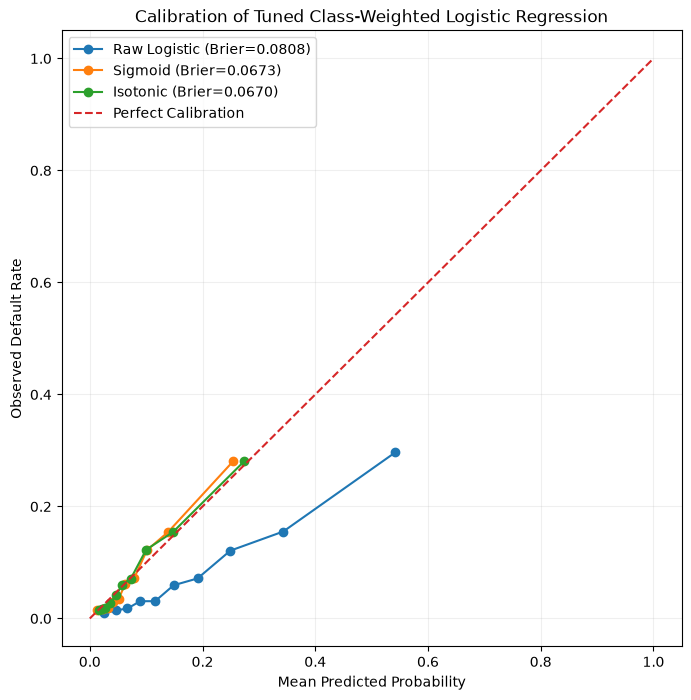

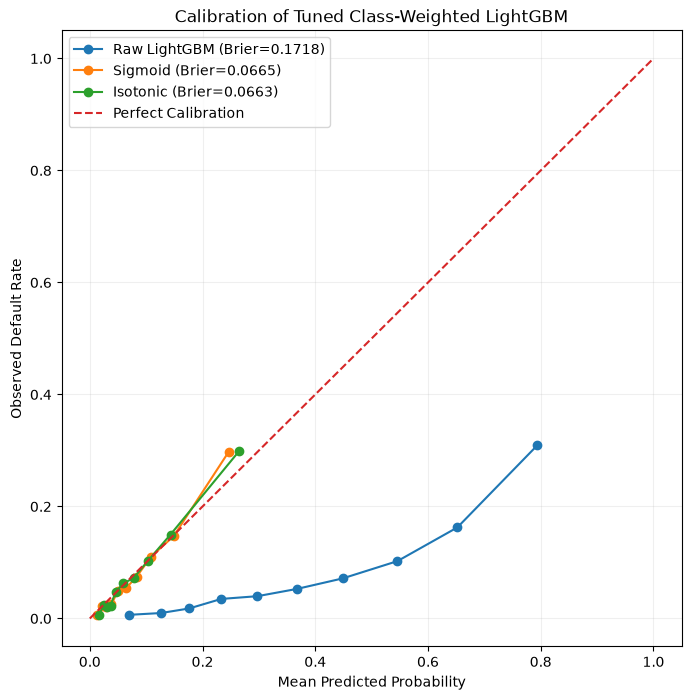

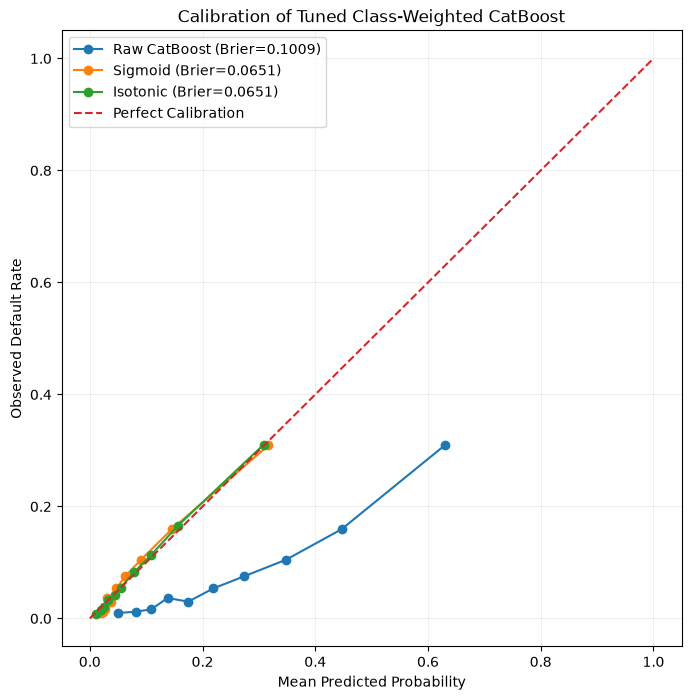


BEST CALIBRATION METHOD FOR EACH TUNED MODEL


,Model,Best Calibration Method,Brier Score,ROC-AUC
0,Tuned Class-Weighted CatBoost,Isotonic,0.0651,0.7968
1,Tuned Class-Weighted LightGBM,Isotonic,0.0663,0.7812
2,Tuned Class-Weighted Logistic Regression,Isotonic,0.0670,0.7753



CALIBRATED MODEL COMPARISON AT THRESHOLD 0.50


,Model,Calibration Method,Brier Score,ROC-AUC,Accuracy,Precision,Recall,F1-score
0,Tuned Class-Weighted CatBoost,Isotonic,0.0651,0.7968,0.9200,0.6452,0.0201,0.0391
1,Tuned Class-Weighted LightGBM,Isotonic,0.0663,0.7812,0.9196,0.5909,0.0131,0.0256
2,Tuned Class-Weighted Logistic Regression,Isotonic,0.0670,0.7753,0.9193,0.5000,0.0111,0.0217



TUNED CLASS-WEIGHTED LOGISTIC REGRESSION - CALIBRATED
               precision    recall  f1-score   support

Non-Defaulter       0.92      1.00      0.96     11308
    Defaulter       0.50      0.01      0.02       993

     accuracy                           0.92     12301
    macro avg       0.71      0.51      0.49     12301
 weighted avg       0.89      0.92      0.88     12301


TUNED CLASS-WEIGHTED LIGHTGBM - CALIBRATED
               precision    recall  f1-score   support

Non-Defaulter       0.92      1.00      0.96     11308
    Defaulter       0.59      0.01      0.03       993

     accuracy                           0.92     12301
    macro avg       0.76      0.51      0.49     12301
 weighted avg       0.89      0.92      0.88     12301


TUNED CLASS-WEIGHTED CATBOOST - CALIBRATED
               precision    recall  f1-score   support

Non-Defaulter       0.92      1.00      0.96     11308
    Defaulter       0.65      0.02      0.04       993

     accuracy           

...

,Raw Probability,Calibrated Probability,Actual Outcome
0,0.3237,0.1708,0
1,0.2746,0.1118,0
2,0.0628,0.0218,0
3,0.0887,0.0465,0
4,0.0587,0.0178,0
5,0.1651,0.1037,0
6,0.1174,0.0253,0
7,0.0243,0.0218,0
8,0.5077,0.2787,0
9,0.0231,0.0178,0



TUNED LIGHTGBM - RAW VS CALIBRATED PROBABILITIES


,Raw Probability,Calibrated Probability,Actual Outcome
0,0.6854,0.2455,0
1,0.5773,0.2069,0
2,0.2637,0.0580,0
3,0.2643,0.0692,0
4,0.2645,0.0179,0
5,0.3157,0.0640,0
6,0.1475,0.0256,0
7,0.0850,0.0212,0
8,0.6267,0.1648,0
9,0.0543,0.0089,0



TUNED CATBOOST - RAW VS CALIBRATED PROBABILITIES


,Raw Probability,Calibrated Probability,Actual Outcome
0,0.4328,0.1290,0
1,0.3299,0.0875,0
2,0.1833,0.0398,0
3,0.1704,0.0360,0
4,0.1175,0.0245,0
5,0.1955,0.0482,0
6,0.1042,0.0208,0
7,0.0643,0.0111,0
8,0.4347,0.1362,0
9,0.0358,0.0062,0


In [39]:
# 12. Calibration Curves

# Tuned Logistic regression


logistic_raw_true, logistic_raw_pred = calibration_curve(
    y_calibration_test,
    logistic_raw_prob,
    n_bins=10,
    strategy="quantile"
)

logistic_sig_true, logistic_sig_pred = calibration_curve(
    y_calibration_test,
    logistic_sigmoid_prob,
    n_bins=10,
    strategy="quantile"
)

logistic_iso_true, logistic_iso_pred = calibration_curve(
    y_calibration_test,
    logistic_isotonic_prob,
    n_bins=10,
    strategy="quantile"
)

# Tuned LightGbM

lgbm_raw_true, lgbm_raw_pred = calibration_curve(
    y_calibration_test,
    lgbm_raw_prob,
    n_bins=10,
    strategy="quantile"
)

lgbm_sig_true, lgbm_sig_pred = calibration_curve(
    y_calibration_test,
    lgbm_sigmoid_prob,
    n_bins=10,
    strategy="quantile"
)

lgbm_iso_true, lgbm_iso_pred = calibration_curve(
    y_calibration_test,
    lgbm_isotonic_prob,
    n_bins=10,
    strategy="quantile"
)

# Tuned Catboost

catboost_raw_true, catboost_raw_pred = calibration_curve(
    y_calibration_test,
    catboost_test_raw_prob,
    n_bins=10,
    strategy="quantile"
)

catboost_sig_true, catboost_sig_pred = calibration_curve(
    y_calibration_test,
    catboost_sigmoid_prob,
    n_bins=10,
    strategy="quantile"
)

catboost_iso_true, catboost_iso_pred = calibration_curve(
    y_calibration_test,
    catboost_isotonic_prob,
    n_bins=10,
    strategy="quantile"
)


# 13. Tuned Logistic Regression Calibration Curve


plt.figure(figsize=(8, 8))

plt.plot(
    logistic_raw_pred,
    logistic_raw_true,
    marker="o",
    label=f"Raw Logistic (Brier={logistic_raw_brier:.4f})"
)

plt.plot(
    logistic_sig_pred,
    logistic_sig_true,
    marker="o",
    label=f"Sigmoid (Brier={logistic_sigmoid_brier:.4f})"
)

plt.plot(
    logistic_iso_pred,
    logistic_iso_true,
    marker="o",
    label=f"Isotonic (Brier={logistic_isotonic_brier:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Rate")

plt.title(
    "Calibration of Tuned Class-Weighted Logistic Regression"
)

plt.legend()

plt.grid(alpha=0.2)

plt.show()


# 14. Tuned LightGBM Calibration Curve


plt.figure(figsize=(8, 8))

plt.plot(
    lgbm_raw_pred,
    lgbm_raw_true,
    marker="o",
    label=f"Raw LightGBM (Brier={lgbm_raw_brier:.4f})"
)

plt.plot(
    lgbm_sig_pred,
    lgbm_sig_true,
    marker="o",
    label=f"Sigmoid (Brier={lgbm_sigmoid_brier:.4f})"
)

plt.plot(
    lgbm_iso_pred,
    lgbm_iso_true,
    marker="o",
    label=f"Isotonic (Brier={lgbm_isotonic_brier:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Rate")

plt.title(
    "Calibration of Tuned Class-Weighted LightGBM"
)

plt.legend()

plt.grid(alpha=0.2)

plt.show()


# 15. Tune Catboost Calibration Curve

plt.figure(figsize=(8, 8))

plt.plot(
    catboost_raw_pred,
    catboost_raw_true,
    marker="o",
    label=f"Raw CatBoost (Brier={catboost_raw_brier:.4f})"
)

plt.plot(
    catboost_sig_pred,
    catboost_sig_true,
    marker="o",
    label=f"Sigmoid (Brier={catboost_sigmoid_brier:.4f})"
)

plt.plot(
    catboost_iso_pred,
    catboost_iso_true,
    marker="o",
    label=f"Isotonic (Brier={catboost_isotonic_brier:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Rate")

plt.title(
    "Calibration of Tuned Class-Weighted CatBoost"
)

plt.legend()

plt.grid(alpha=0.2)

plt.show()



# 16. Select Best Calibration Method For Each Model
# Tuned Logistic Regression


if logistic_sigmoid_brier <= logistic_isotonic_brier:

    best_logistic_calibration = calibrated_logistic_sigmoid

    best_logistic_calibration_prob = (
        logistic_sigmoid_prob
    )

    logistic_calibration_method = "Sigmoid"

    logistic_selected_brier = logistic_sigmoid_brier

else:

    best_logistic_calibration = calibrated_logistic_isotonic

    best_logistic_calibration_prob = (
        logistic_isotonic_prob
    )

    logistic_calibration_method = "Isotonic"

    logistic_selected_brier = logistic_isotonic_brier


# Tuned Lightgbm


if lgbm_sigmoid_brier <= lgbm_isotonic_brier:

    best_lgbm_calibration = calibrated_lgbm_sigmoid

    best_lgbm_calibration_prob = (
        lgbm_sigmoid_prob
    )

    lgbm_calibration_method = "Sigmoid"

    lgbm_selected_brier = lgbm_sigmoid_brier

else:

    best_lgbm_calibration = calibrated_lgbm_isotonic

    best_lgbm_calibration_prob = (
        lgbm_isotonic_prob
    )

    lgbm_calibration_method = "Isotonic"

    lgbm_selected_brier = lgbm_isotonic_brier


# Tuned Catboost

if catboost_sigmoid_brier <= catboost_isotonic_brier:

    best_catboost_calibration = (
        catboost_sigmoid_calibrator
    )

    best_catboost_calibration_prob = (
        catboost_sigmoid_prob
    )

    catboost_calibration_method = "Sigmoid"

    catboost_selected_brier = catboost_sigmoid_brier

else:

    best_catboost_calibration = (
        catboost_isotonic_calibrator
    )

    best_catboost_calibration_prob = (
        catboost_isotonic_prob
    )

    catboost_calibration_method = "Isotonic"

    catboost_selected_brier = catboost_isotonic_brier


# 17. Display Best Calibration Method


best_calibration_summary = pd.DataFrame({

    "Model": [
        "Tuned Class-Weighted Logistic Regression",
        "Tuned Class-Weighted LightGBM",
        "Tuned Class-Weighted CatBoost"
    ],

    "Best Calibration Method": [
        logistic_calibration_method,
        lgbm_calibration_method,
        catboost_calibration_method
    ],

    "Brier Score": [
        logistic_selected_brier,
        lgbm_selected_brier,
        catboost_selected_brier
    ],

    "ROC-AUC": [

        roc_auc_score(
            y_calibration_test,
            best_logistic_calibration_prob
        ),

        roc_auc_score(
            y_calibration_test,
            best_lgbm_calibration_prob
        ),

        roc_auc_score(
            y_calibration_test,
            best_catboost_calibration_prob
        )
    ]
})


print("\nBEST CALIBRATION METHOD FOR EACH TUNED MODEL")
print("=" * 90)

display(
    best_calibration_summary
    .sort_values(
        "Brier Score"
    )
    .reset_index(drop=True)
    .round(4)
)


# 18. Classification at Threshold 0.50

# 0.50 is used only as a common comparison threshold. It is NOT the final business threshold.
# The final threshold will be selected later using cost-sensitive threshold analysis.


COMPARISON_THRESHOLD = 0.50


# Tuned Logistic Regression


logistic_calibrated_pred = (
    best_logistic_calibration_prob >= COMPARISON_THRESHOLD
).astype(int)


# Tuned Lightgbm


lgbm_calibrated_pred = (
    best_lgbm_calibration_prob >= COMPARISON_THRESHOLD
).astype(int)


# Tuned Catboost


catboost_calibrated_pred = (
    best_catboost_calibration_prob >= COMPARISON_THRESHOLD
).astype(int)

# 19. Calibrated Model Comparison


calibrated_model_comparison = pd.DataFrame({

    "Model": [
        "Tuned Class-Weighted Logistic Regression",
        "Tuned Class-Weighted LightGBM",
        "Tuned Class-Weighted CatBoost"
    ],

    "Calibration Method": [
        logistic_calibration_method,
        lgbm_calibration_method,
        catboost_calibration_method
    ],

    "Brier Score": [
        logistic_selected_brier,
        lgbm_selected_brier,
        catboost_selected_brier
    ],

    "ROC-AUC": [

        roc_auc_score(
            y_calibration_test,
            best_logistic_calibration_prob
        ),

        roc_auc_score(
            y_calibration_test,
            best_lgbm_calibration_prob
        ),

        roc_auc_score(
            y_calibration_test,
            best_catboost_calibration_prob
        )
    ],

    "Accuracy": [

        accuracy_score(
            y_calibration_test,
            logistic_calibrated_pred
        ),

        accuracy_score(
            y_calibration_test,
            lgbm_calibrated_pred
        ),

        accuracy_score(
            y_calibration_test,
            catboost_calibrated_pred
        )
    ],

    "Precision": [

        precision_score(
            y_calibration_test,
            logistic_calibrated_pred,
            zero_division=0
        ),

        precision_score(
            y_calibration_test,
            lgbm_calibrated_pred,
            zero_division=0
        ),

        precision_score(
            y_calibration_test,
            catboost_calibrated_pred,
            zero_division=0
        )
    ],

    "Recall": [

        recall_score(
            y_calibration_test,
            logistic_calibrated_pred,
            zero_division=0
        ),

        recall_score(
            y_calibration_test,
            lgbm_calibrated_pred,
            zero_division=0
        ),

        recall_score(
            y_calibration_test,
            catboost_calibrated_pred,
            zero_division=0
        )
    ],

    "F1-score": [

        f1_score(
            y_calibration_test,
            logistic_calibrated_pred,
            zero_division=0
        ),

        f1_score(
            y_calibration_test,
            lgbm_calibrated_pred,
            zero_division=0
        ),

        f1_score(
            y_calibration_test,
            catboost_calibrated_pred,
            zero_division=0
        )
    ]
})


print("\nCALIBRATED MODEL COMPARISON AT THRESHOLD 0.50")
print("=" * 100)

display(
    calibrated_model_comparison
    .sort_values(
        "Brier Score"
    )
    .reset_index(drop=True)
    .round(4)
)



# 20. Classification Report: Tuned Logistic Regression

print(
    "\nTUNED CLASS-WEIGHTED LOGISTIC REGRESSION - CALIBRATED"
)

print("=" * 80)

print(
    classification_report(
        y_calibration_test,
        logistic_calibrated_pred,
        target_names=[
            "Non-Defaulter",
            "Defaulter"
        ]
    )
)

# 21. Classification Report: Tuned Lightgbm

print(
    "\nTUNED CLASS-WEIGHTED LIGHTGBM - CALIBRATED"
)

print("=" * 80)

print(
    classification_report(
        y_calibration_test,
        lgbm_calibrated_pred,
        target_names=[
            "Non-Defaulter",
            "Defaulter"
        ]
    )
)



# 22. # 20. Classification Report: Tuned Catboost


print(
    "\nTUNED CLASS-WEIGHTED CATBOOST - CALIBRATED"
)

print("=" * 80)

print(
    classification_report(
        y_calibration_test,
        catboost_calibrated_pred,
        target_names=[
            "Non-Defaulter",
            "Defaulter"
        ]
    )
)


# 23. Confusion Matrix Values
# Tuned Logistic Regression

logistic_tn, logistic_fp, logistic_fn, logistic_tp = (
    confusion_matrix(
        y_calibration_test,
        logistic_calibrated_pred
    ).ravel()
)


# Tuned Lightgbm

lgbm_tn, lgbm_fp, lgbm_fn, lgbm_tp = (
    confusion_matrix(
        y_calibration_test,
        lgbm_calibrated_pred
    ).ravel()
)

# Tuned Catboost

catboost_tn, catboost_fp, catboost_fn, catboost_tp = (
    confusion_matrix(
        y_calibration_test,
        catboost_calibrated_pred
    ).ravel()
)


# 24. Confusion matrix comparison

confusion_summary = pd.DataFrame({

    "Model": [
        "Tuned Class-Weighted Logistic Regression",
        "Tuned Class-Weighted LightGBM",
        "Tuned Class-Weighted CatBoost"
    ],

    "True Negatives": [
        logistic_tn,
        lgbm_tn,
        catboost_tn
    ],

    "False Positives": [
        logistic_fp,
        lgbm_fp,
        catboost_fp
    ],

    "False Negatives": [
        logistic_fn,
        lgbm_fn,
        catboost_fn
    ],

    "True Positives": [
        logistic_tp,
        lgbm_tp,
        catboost_tp
    ]
})


print("\nCONFUSION MATRIX COMPARISON AT THRESHOLD 0.50")
print("=" * 90)

display(
    confusion_summary.round(0)
)

# 25. Calibrated Probability Examples
# Tuned Logistic Regression


logistic_probability_comparison = pd.DataFrame({

    "Raw Probability": logistic_raw_prob[:20],

    "Calibrated Probability":
        best_logistic_calibration_prob[:20],

    "Actual Outcome":
        y_calibration_test.iloc[:20].values
})


print(
    "\nTUNED LOGISTIC REGRESSION - "
    "RAW VS CALIBRATED PROBABILITIES"
)

print("=" * 80)

display(
    logistic_probability_comparison.round(4)
)



#Tuned Lightgbm

lgbm_probability_comparison = pd.DataFrame({

    "Raw Probability": lgbm_raw_prob[:20],

    "Calibrated Probability":
        best_lgbm_calibration_prob[:20],

    "Actual Outcome":
        y_calibration_test.iloc[:20].values
})


print(
    "\nTUNED LIGHTGBM - "
    "RAW VS CALIBRATED PROBABILITIES"
)

print("=" * 80)

display(
    lgbm_probability_comparison.round(4)
)


# Tuned Catboost

catboost_probability_comparison = pd.DataFrame({

    "Raw Probability": catboost_test_raw_prob[:20],

    "Calibrated Probability":
        best_catboost_calibration_prob[:20],

    "Actual Outcome":
        y_calibration_test.iloc[:20].values
})


print(
    "\nTUNED CATBOOST - "
    "RAW VS CALIBRATED PROBABILITIES"
)

print("=" * 80)

display(
    catboost_probability_comparison.round(4)
)




## Calibration Results Interpretation

### 1. Calibration Curves

The raw models are generally **poorly calibrated and tend to overestimate default risk**, particularly at higher predicted probabilities. LightGBM has the poorest raw calibration (**Brier Score = 0.1718**), followed by CatBoost (**0.1009**) and Logistic Regression (**0.0808**).

After calibration, all three models show substantial improvement, with their Brier Scores decreasing to approximately **0.065–0.067**. This indicates that calibration made the predicted probabilities more consistent with the observed default rates.

### 2. Best Calibration Method

**Isotonic calibration performed best for all three tuned models:**

| Model | Best Method | Brier Score | ROC-AUC |
|---|---|---:|---:|
| Tuned CatBoost | Isotonic | **0.0651** | **0.7968** |
| Tuned LightGBM | Isotonic | 0.0663 | 0.7812 |
| Tuned Logistic Regression | Isotonic | 0.0670 | 0.7753 |

Tuned CatBoost with Isotonic calibration achieved the **lowest Brier Score and highest ROC-AUC**, making it the best-calibrated model.

### 3. Threshold of 0.50

Despite the improved calibration, using a **0.50 threshold resulted in very low defaulter recall**:

- CatBoost: **2.01%**
- LightGBM: **1.31%**
- Logistic Regression: **1.11%**

For example, CatBoost identified only **20 out of 993 actual defaulters**, while missing 973.

This demonstrates that **0.50 is not an appropriate decision threshold** for this imbalanced credit-risk problem. The calibrated probabilities should instead be combined with **cost-sensitive threshold analysis** to determine a more suitable operating threshold.

### Overall Conclusion

> **Tuned CatBoost with Isotonic calibration achieved the best calibration performance (Brier Score = 0.0651; ROC-AUC = 0.7968). However, the 0.50 threshold produced extremely low defaulter recall. Therefore, the final threshold should be selected using cost-sensitive analysis, where the cost of missing a defaulter is given greater importance than the cost of a false positive.**

### Cost sensitive threshold analysis using Calibrated probabilities 

The lowest-cost threshold will selected using the assumed business costs:
1. **False Positive = 1**
2. **False Negative = 5**

This threshold will not be treated as universally optimal, It will depends on the chosen business cost assumptions.
 
The final model decision should consider:
- Total business cost
- Recall
- Precision
- F1-score
- Number of false negatives
- Number of false positives
- ROC-AUC
- Brier Score
- Calibration quality

The final untouched test set should be used for the final unbiased evaluation after the model and threshold are selected.

In [ ]:


# We use the BEST CALIBRATED probability from each model.
#
# Business assumption:
# False Positive cost = 1
# False Negative cost = 5
#
# A False Negative is therefore 5 times more costly than  a False Positive.


# 1. Define Thresholds

# Lower thresholds are included because calibration compressed the predicted probabilities toward the actual default rate.
# This allows us to investigate thresholds below 0.50.

thresholds = [
    0.50,
    0.40,
    0.30,
    0.20,
    0.15,
    0.10,
    0.08,
    0.05,
    0.03,
    0.01
]


# 2. Define Business costs


FP_COST = 1
FN_COST = 5


# 3. Use the best calibrated probabilities

# Tuned Logistic Regression
logistic_final_prob = best_logistic_calibration_prob


# Tuned LightGBM
lgbm_final_prob = best_lgbm_calibration_prob


# Tuned CatBoost
catboost_final_prob = best_catboost_calibration_prob


# 4. Cost Analysis Function

def calculate_cost_analysis(
    y_true,
    probabilities,
    thresholds,
    fp_cost,
    fn_cost
):

    results = []

    for threshold in thresholds:

        
        # Convert probabilities into predictions
      

        predictions = (
            probabilities >= threshold
        ).astype(int)


        
        # Confusion matrix
        

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            predictions
        ).ravel()


        
        # Calculate business cost
       

        total_cost = (
            (fp * fp_cost) +
            (fn * fn_cost)
        )


       
        # Performance metrics
        

        accuracy = accuracy_score(
            y_true,
            predictions
        )

        precision = precision_score(
            y_true,
            predictions,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            predictions,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            predictions,
            zero_division=0
        )


        
        # Store results
        

        results.append({

            "Threshold": threshold,

            "Accuracy": accuracy,

            "Precision": precision,

            "Recall": recall,

            "F1-score": f1,

            "False Positives": fp,

            "False Negatives": fn,

            "True Positives": tp,

            "True Negatives": tn,

            "Total Cost": total_cost
        })


    return pd.DataFrame(results)


# 5. Logistic Regression Cost Analysis

logistic_cost_results = calculate_cost_analysis(

    y_calibration_test,

    logistic_final_prob,

    thresholds,

    FP_COST,

    FN_COST
)


print("\nTUNED CLASS-WEIGHTED LOGISTIC REGRESSION")
print("COST-SENSITIVE THRESHOLD ANALYSIS")
print("=" * 100)

print(f"False Positive Cost : {FP_COST}")
print(f"False Negative Cost : {FN_COST}")

display(

    logistic_cost_results

    .sort_values(
        "Total Cost"
    )

    .round(4)

# 6. LightGBM cost analysis

lgbm_cost_results = calculate_cost_analysis(

    y_calibration_test,

    lgbm_final_prob,

    thresholds,

    FP_COST,

    FN_COST
)


print("\nTUNED CLASS-WEIGHTED LIGHTGBM")
print("COST-SENSITIVE THRESHOLD ANALYSIS")
print("=" * 100)

print(f"False Positive Cost : {FP_COST}")
print(f"False Negative Cost : {FN_COST}")

display(

    lgbm_cost_results

    .sort_values(
        "Total Cost"
    )

    .round(4)
)


# 7. Catboost cost analysis

catboost_cost_results = calculate_cost_analysis(

    y_calibration_test,

    catboost_final_prob,

    thresholds,

    FP_COST,

    FN_COST
)


print("\nTUNED CLASS-WEIGHTED CATBOOST")
print("COST-SENSITIVE THRESHOLD ANALYSIS")
print("=" * 100)

print(f"False Positive Cost : {FP_COST}")
print(f"False Negative Cost : {FN_COST}")

display(

    catboost_cost_results

    .sort_values(
        "Total Cost"
    )

    .round(4)
)


# 8. Find the lowest - cost threshold for each model


best_logistic_cost = (

    logistic_cost_results

    .loc[
        logistic_cost_results[
            "Total Cost"
        ].idxmin()
    ]
)


best_lgbm_cost = (

    lgbm_cost_results

    .loc[
        lgbm_cost_results[
            "Total Cost"
        ].idxmin()
    ]
)


best_catboost_cost = (

    catboost_cost_results

    .loc[
        catboost_cost_results[
            "Total Cost"
        ].idxmin()
    ]
)


# 9. Final Cost Comparison


calibrated_cost_summary = pd.DataFrame({

    "Model": [

        "Tuned Class-Weighted Logistic Regression",

        "Tuned Class-Weighted LightGBM",

        "Tuned Class-Weighted CatBoost"
    ],


    "Best Threshold": [

        best_logistic_cost[
            "Threshold"
        ],

        best_lgbm_cost[
            "Threshold"
        ],

        best_catboost_cost[
            "Threshold"
        ]
    ],


    "Accuracy": [

        best_logistic_cost[
            "Accuracy"
        ],

        best_lgbm_cost[
            "Accuracy"
        ],

        best_catboost_cost[
            "Accuracy"
        ]
    ],


    "Precision": [

        best_logistic_cost[
            "Precision"
        ],

        best_lgbm_cost[
            "Precision"
        ],

        best_catboost_cost[
            "Precision"
        ]
    ],


    "Recall": [

        best_logistic_cost[
            "Recall"
        ],

        best_lgbm_cost[
            "Recall"
        ],

        best_catboost_cost[
            "Recall"
        ]
    ],


    "F1-score": [

        best_logistic_cost[
            "F1-score"
        ],

        best_lgbm_cost[
            "F1-score"
        ],

        best_catboost_cost[
            "F1-score"
        ]
    ],


    "False Positives": [

        best_logistic_cost[
            "False Positives"
        ],

        best_lgbm_cost[
            "False Positives"
        ],

        best_catboost_cost[
            "False Positives"
        ]
    ],


    "False Negatives": [

        best_logistic_cost[
            "False Negatives"
        ],

        best_lgbm_cost[
            "False Negatives"
        ],

        best_catboost_cost[
            "False Negatives"
        ]
    ],


    "True Positives": [

        best_logistic_cost[
            "True Positives"
        ],

        best_lgbm_cost[
            "True Positives"
        ],

        best_catboost_cost[
            "True Positives"
        ]
    ],


    "True Negatives": [

        best_logistic_cost[
            "True Negatives"
        ],

        best_lgbm_cost[
            "True Negatives"
        ],

        best_catboost_cost[
            "True Negatives"
        ]
    ],


    "Total Cost": [

        best_logistic_cost[
            "Total Cost"
        ],

        best_lgbm_cost[
            "Total Cost"
        ],

        best_catboost_cost[
            "Total Cost"
        ]
    ]
})


# 10. Display final cost comparison

print(
    "\nBEST COST-SENSITIVE RESULT "
    "USING CALIBRATED PROBABILITIES"
)

print("=" * 110)

display(

    calibrated_cost_summary

    .sort_values(
        "Total Cost"
    )

    .reset_index(
        drop=True
    )

    .round(4)
)


# 11. Identify overall lowest-cost model


best_overall_cost = (

    calibrated_cost_summary

    .loc[
        calibrated_cost_summary[
            "Total Cost"
        ].idxmin()
    ]
)


print("\nOVERALL LOWEST-COST MODEL")
print("=" * 90)

print(
    f"Model          : "
    f"{best_overall_cost['Model']}"
)

print(
    f"Threshold      : "
    f"{best_overall_cost['Best Threshold']}"
)

print(
    f"Total Cost     : "
    f"{best_overall_cost['Total Cost']:.0f}"
)

print(
    f"Precision      : "
    f"{best_overall_cost['Precision']:.4f}"
)

print(
    f"Recall         : "
    f"{best_overall_cost['Recall']:.4f}"
)

print(
    f"F1-score       : "
    f"{best_overall_cost['F1-score']:.4f}"
)

print(
    f"False Positives: "
    f"{best_overall_cost['False Positives']:.0f}"
)

print(
    f"False Negatives: "
    f"{best_overall_cost['False Negatives']:.0f}"
)



# ============================================================




TUNED CLASS-WEIGHTED LOGISTIC REGRESSION
COST-SENSITIVE THRESHOLD ANALYSIS
False Positive Cost : 1
False Negative Cost : 5


,Threshold,Accuracy,Precision,Recall,F1-score,False Positives,False Negatives,True Positives,True Negatives,Total Cost
4,0.15,0.8497,0.2517,0.4371,0.3195,1290,559,434,10018,4085
3,0.20,0.8820,0.2927,0.3263,0.3086,783,669,324,10525,4128
5,0.10,0.7683,0.2002,0.6244,0.3032,2477,373,620,8831,4342
2,0.30,0.9138,0.3943,0.1259,0.1908,192,868,125,11116,4532
6,0.08,0.7183,0.1803,0.7019,0.2869,3169,296,697,8139,4649
1,0.40,0.9197,0.5238,0.0554,0.1002,50,938,55,11258,4740
0,0.50,0.9193,0.5000,0.0111,0.0217,11,982,11,11297,4921
7,0.05,0.5402,0.1347,0.8661,0.2332,5523,133,860,5785,6188
8,0.03,0.3666,0.1076,0.9386,0.1931,7730,61,932,3578,8035
9,0.01,0.0817,0.0807,0.9980,0.1493,11294,2,991,14,11304



TUNED CLASS-WEIGHTED LIGHTGBM
COST-SENSITIVE THRESHOLD ANALYSIS
False Positive Cost : 1
False Negative Cost : 5


,Threshold,Accuracy,Precision,Recall,F1-score,False Positives,False Negatives,True Positives,True Negatives,Total Cost
3,0.20,0.8928,0.3302,0.3192,0.3246,643,676,317,10665,4023
4,0.15,0.8550,0.2613,0.4361,0.3268,1224,560,433,10084,4024
5,0.10,0.7647,0.2003,0.6395,0.3050,2536,358,635,8772,4326
2,0.30,0.9157,0.4329,0.1430,0.2150,186,851,142,11122,4441
6,0.08,0.6967,0.1733,0.7311,0.2801,3464,267,726,7844,4799
1,0.40,0.9198,0.5493,0.0393,0.0733,32,954,39,11276,4802
0,0.50,0.9196,0.5909,0.0131,0.0256,9,980,13,11299,4909
7,0.05,0.5455,0.1346,0.8530,0.2325,5445,146,847,5863,6175
8,0.03,0.3250,0.1024,0.9476,0.1848,8251,52,941,3057,8511
9,0.01,0.0884,0.0814,1.0000,0.1505,11213,0,993,95,11213



TUNED CLASS-WEIGHTED CATBOOST
COST-SENSITIVE THRESHOLD ANALYSIS
False Positive Cost : 1
False Negative Cost : 5


,Threshold,Accuracy,Precision,Recall,F1-score,False Positives,False Negatives,True Positives,True Negatives,Total Cost
4,0.15,0.8629,0.2811,0.4481,0.3455,1138,548,445,10170,3878
3,0.20,0.8817,0.3107,0.3817,0.3425,841,614,379,10467,3911
5,0.10,0.7680,0.2073,0.6636,0.3159,2520,334,659,8788,4190
2,0.30,0.9134,0.4253,0.2064,0.2780,277,788,205,11031,4217
1,0.40,0.9194,0.5025,0.0997,0.1664,98,894,99,11210,4568
6,0.08,0.7104,0.1821,0.7412,0.2924,3305,257,736,8003,4590
0,0.50,0.9200,0.6452,0.0201,0.0391,11,973,20,11297,4876
7,0.05,0.5935,0.1476,0.8449,0.2513,4846,154,839,6462,5616
8,0.03,0.4326,0.1176,0.9265,0.2086,6906,73,920,4402,7271
9,0.01,0.1246,0.0841,0.9960,0.1552,10764,4,989,544,10784



BEST COST-SENSITIVE RESULT USING CALIBRATED PROBABILITIES


,Model,Best Threshold,Accuracy,Precision,Recall,F1-score,False Positives,False Negatives,True Positives,True Negatives,Total Cost
0,Tuned Class-Weighted CatBoost,0.15,0.8629,0.2811,0.4481,0.3455,1138.0,548.0,445.0,10170.0,3878.0
1,Tuned Class-Weighted LightGBM,0.20,0.8928,0.3302,0.3192,0.3246,643.0,676.0,317.0,10665.0,4023.0
2,Tuned Class-Weighted Logistic Regression,0.15,0.8497,0.2517,0.4371,0.3195,1290.0,559.0,434.0,10018.0,4085.0



OVERALL LOWEST-COST MODEL
Model          : Tuned Class-Weighted CatBoost
Threshold      : 0.15
Total Cost     : 3878
Precision      : 0.2811
Recall         : 0.4481
F1-score       : 0.3455
False Positives: 1138
False Negatives: 548


## Cost-Sensitive Threshold Analysis

Cost-sensitive threshold analysis was performed using the best calibrated probabilities from the three tuned class-weighted models. A false positive was assigned a cost of 1, while a false negative was assigned a cost of 5, reflecting the assumption that failing to identify a genuine defaulter is more costly than incorrectly flagging a non-defaulter.

The results show that a threshold of **0.50 is not appropriate** for any of the models because it produces extremely low recall. Lowering the threshold substantially improves the detection of defaulters while increasing the number of false positives.

### Best Cost-Sensitive Results

| Model | Best Threshold | Precision | Recall | F1-score | False Positives | False Negatives | Total Cost |
|---|---:|---:|---:|---:|---:|---:|---:|
| **Tuned Class-Weighted CatBoost** | **0.15** | 28.11% | **44.81%** | **34.55%** | 1,138 | 548 | **3,878** |
| Tuned Class-Weighted LightGBM | 0.20 | 33.02% | 31.92% | 32.46% | 643 | 676 | 4,023 |
| Tuned Class-Weighted Logistic Regression | 0.15 | 25.17% | 43.71% | 31.95% | 1,290 | 559 | 4,085 |

Based on the assumed business costs, **Tuned Class-Weighted CatBoost with a threshold of 0.15 produced the lowest total cost of 3,878**. It also achieved the highest recall (44.81%) and F1-score (34.55%) among the three models at their respective cost-optimal thresholds.

Although LightGBM achieved higher precision (33.02%) and fewer false positives, it missed more actual defaulters and therefore had a higher total cost. Logistic Regression also achieved relatively high recall but generated more false positives and had a higher overall cost.

Therefore, under the assumed **False Positive : False Negative cost ratio of 1 : 5**, **Tuned Class-Weighted CatBoost with a 0.15 threshold is the preferred model and operating threshold**.

However, this selection is based on the assumed business costs. In a real credit-risk setting, the cost ratio should ideally be determined using actual financial consequences of approving a risky applicant versus incorrectly rejecting a good applicant.

## Final Model selection and saving 

In [ ]:
# Saving the  final model with preprocessing information



OUTPUT_DIR = Path("output")

final_model_package = {

    # Model
    "model_name": "Tuned Class-Weighted CatBoost",
    "model": final_model,

    # Calibration
    "calibrator": final_calibrator,
    "calibration_method": "Isotonic",

    # Decision threshold
    "threshold": 0.15,

    # Business costs
    "false_positive_cost": 1,
    "false_negative_cost": 5,

    # Model selection
    "selection_criteria": "Lowest total business cost",

    # Final performance
    "total_cost": 3878,
    "accuracy": 0.8629,
    "precision": 0.2811,
    "recall": 0.4481,
    "f1_score": 0.3455,

    "false_positives": 1138,
    "false_negatives": 548,
    "true_positives": 445,
    "true_negatives": 10170,

    # IMPORTANT: preprocessing information
    "training_columns": list(X_train.columns),

    # Identify categorical columns
    "categorical_columns": list(
        X_train.select_dtypes(
            include=["object", "category"]
        ).columns
    )
}


# Save
final_model_path = (
    OUTPUT_DIR / "final_credit_risk_model.pkl"
)

joblib.dump(
    final_model_package,
    final_model_path
)

print("FINAL MODEL PACKAGE SAVED")
print("=" * 80)

print("Training columns:",
      len(final_model_package["training_columns"]))

print("Categorical columns:",
      len(final_model_package["categorical_columns"]))

print("Model:",
      final_model_package["model_name"])

print("Calibration:",
      final_model_package["calibration_method"])

print("Threshold:",
      final_model_package["threshold"])

FINAL MODEL PACKAGE SAVED
Training columns: 842
Categorical columns: 0
Model: Tuned Class-Weighted CatBoost
Calibration: Isotonic
Threshold: 0.15


In [ ]:
#. Verifying the saved model


loaded_final_model = joblib.load(
    final_model_path
)


print("\nSAVED MODEL VERIFICATION")
print("=" * 80)

print(
    "Model:",
    loaded_final_model["model_name"]
)

print(
    "Calibration:",
    loaded_final_model["calibration_method"]
)

print(
    "Threshold:",
    loaded_final_model["threshold"]
)

print(
    "Total Cost:",
    loaded_final_model["total_cost"]
)


SAVED MODEL VERIFICATION
Model: Tuned Class-Weighted CatBoost
Calibration: Isotonic
Threshold: 0.15
Total Cost: 3878
